## Setup for EDA and time series 

In [71]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [72]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Data Viz. 
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.ndimage import gaussian_filter
from calendar import monthrange
from calendar import month_name
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report

from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing


from statsmodels.tsa.statespace.sarimax import SARIMAX
#New Libraries
#from statsmodels.tsa.statespace.sarimax import SARIMAX
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'
cmaps_hex = ['#193251','#FF5A36','#696969', '#7589A2','#FF5A36', '#DB6668']
sns.set_palette(palette=cmaps_hex)
sns_c = sns.color_palette(palette=cmaps_hex)
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100


In [73]:
#from statsmodels.tsa.stattools import adfuller
#!pip install pmdarima --quiet
#import pmdarima as pm


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 
- df_dt is final dataframe for XG Boost regressor (only contain the 'datatime' and  'target' features)

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [74]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [75]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [76]:
#res_df.dtypes

In [77]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [78]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [79]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [80]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [81]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [82]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [83]:
data_df_gwh = data_df_mwh.copy()

In [84]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [85]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [86]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [87]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [88]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [89]:

data_df= data_df_gwh.copy()

In [90]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [91]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [92]:
##data_df.columns

In [93]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [94]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files

main_0  = 'Total_energy_generation_gwh' # This is only for energy
title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy

#main_0  = 'Solar_gwh' # for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Total energy generation in GWh
Total energy generation(GWh)


### Here we set the function for line plot  

In [95]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



In [96]:

def average_lineplot_no_group_eng(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average total energy generation in Germany by month', ylabel= 'Total energy generation energy (GWh)');
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()


def average_lineplot_no_group_sol(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average solar energy generation in Germany by month', ylabel='Solar energy generation (GWh)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()

def average_lineplot_no_group_ren(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average other renewable energy generation in Germany by month', ylabel='Other renewable energy generation (GWh)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()   


#target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh'



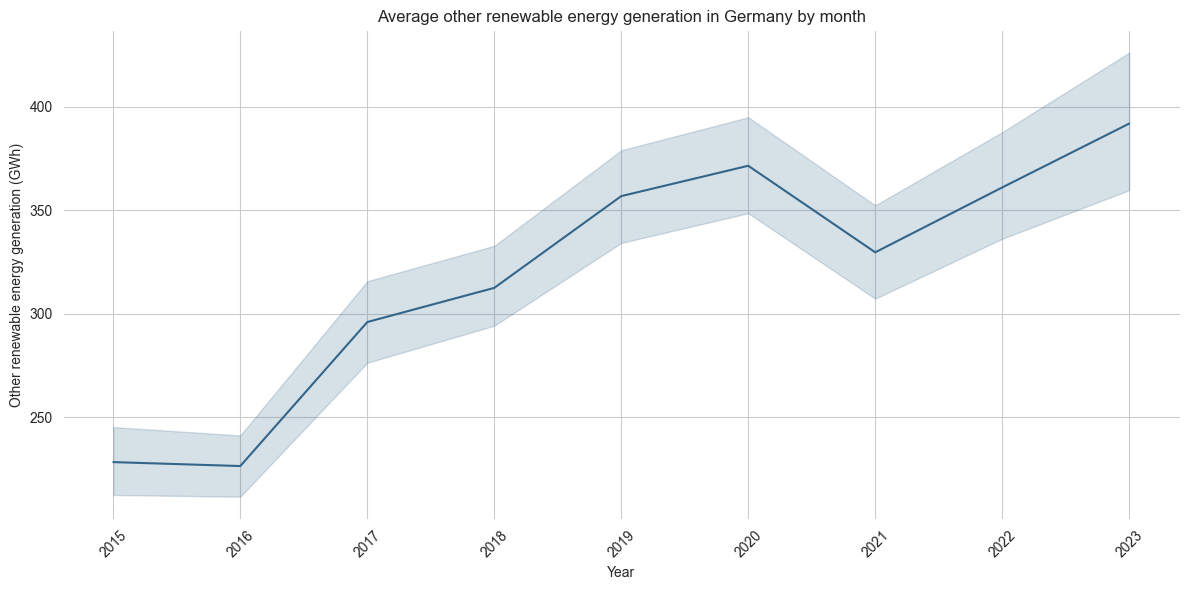

In [97]:
average_lineplot_no_group_ren(df=data_df, y='Total_other_renewable_gwh', x="Date", time='Year')

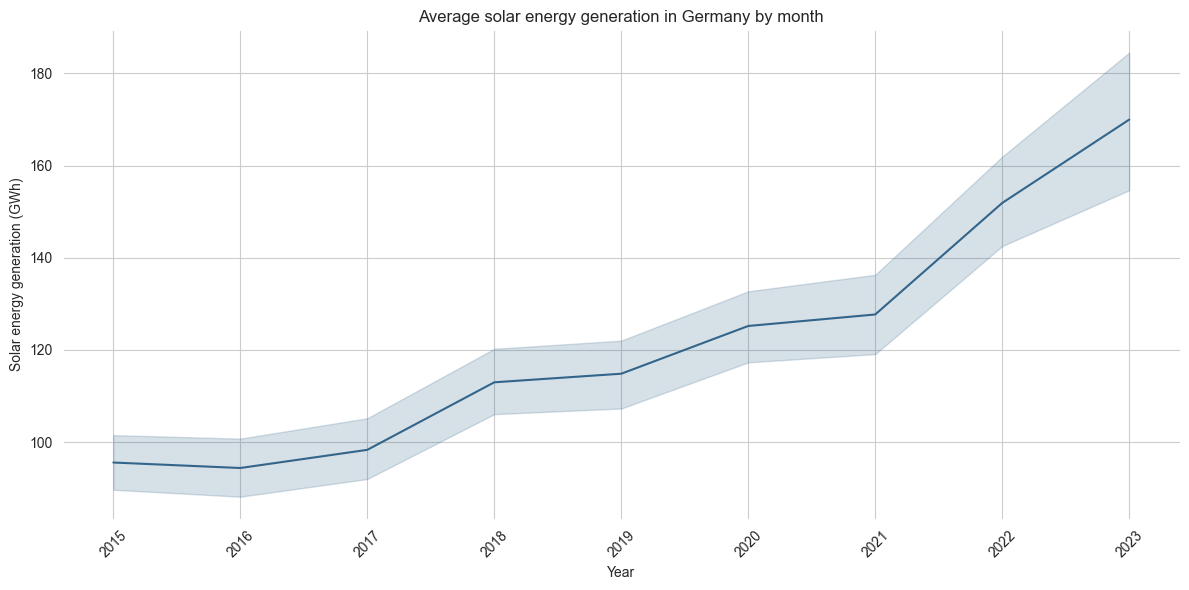

In [98]:
average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Year')

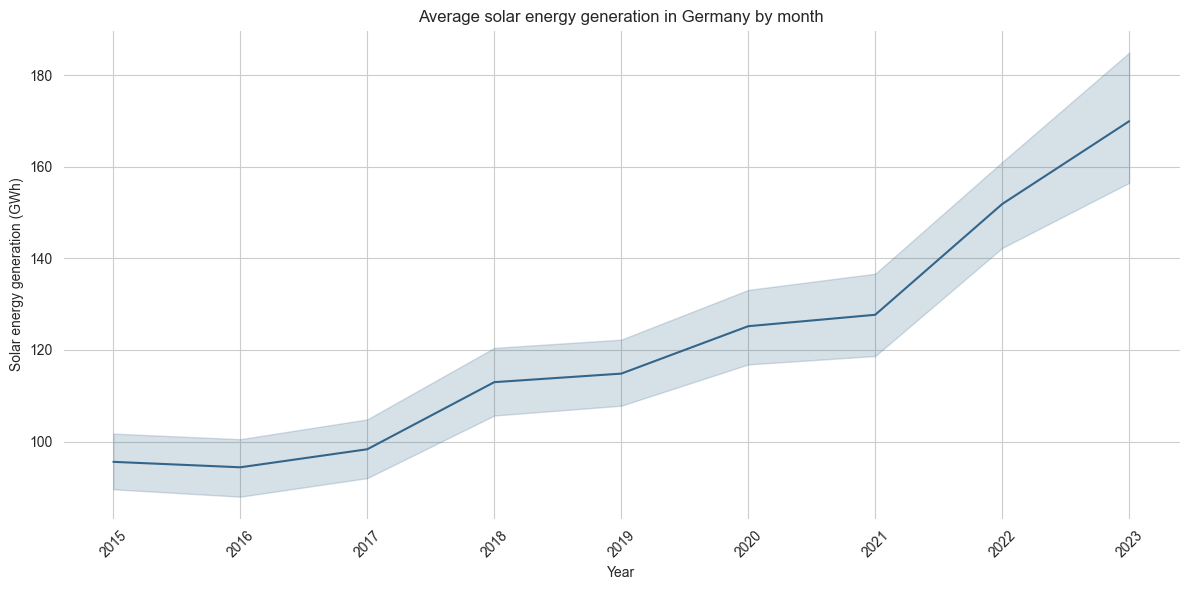

In [99]:
average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Year')

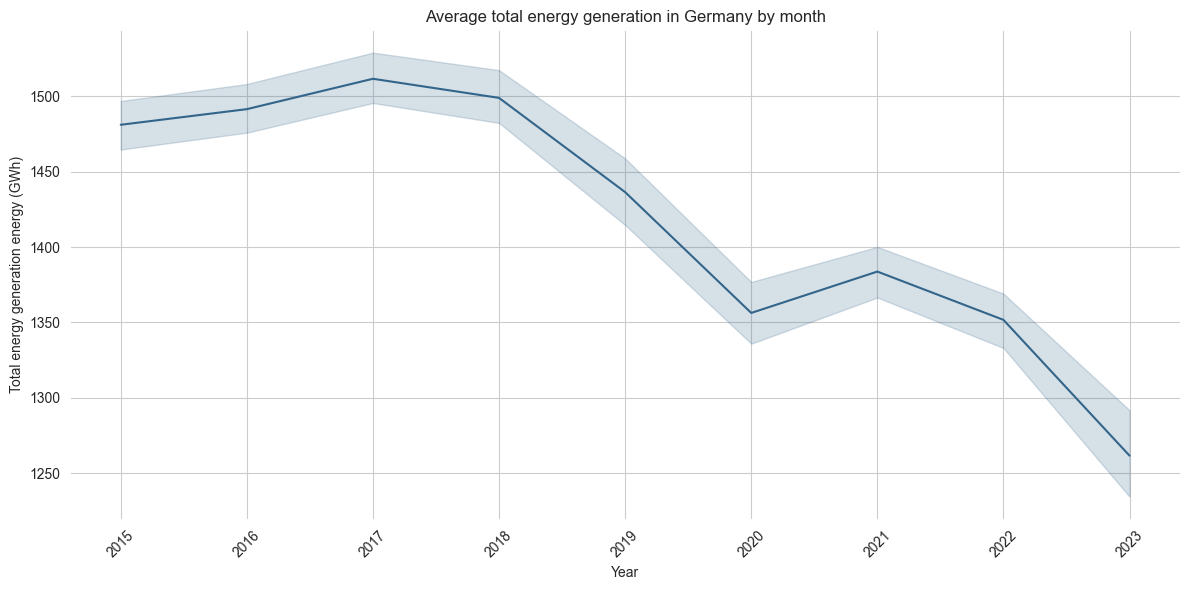

In [100]:
'Total_energy_generation_gwh'
average_lineplot_no_group_eng(df=data_df, y= 'Total_energy_generation_gwh', x="Date", time='Year')
#average_lineplot_no_group_eng(df=data_df, y= target, x="Date", time='Year')

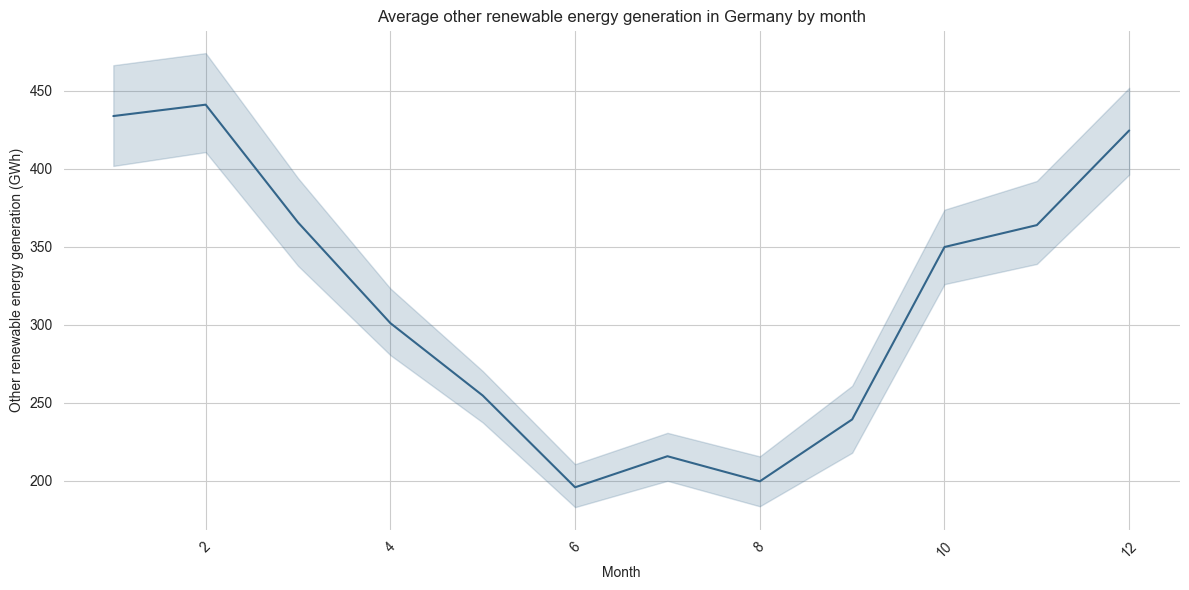

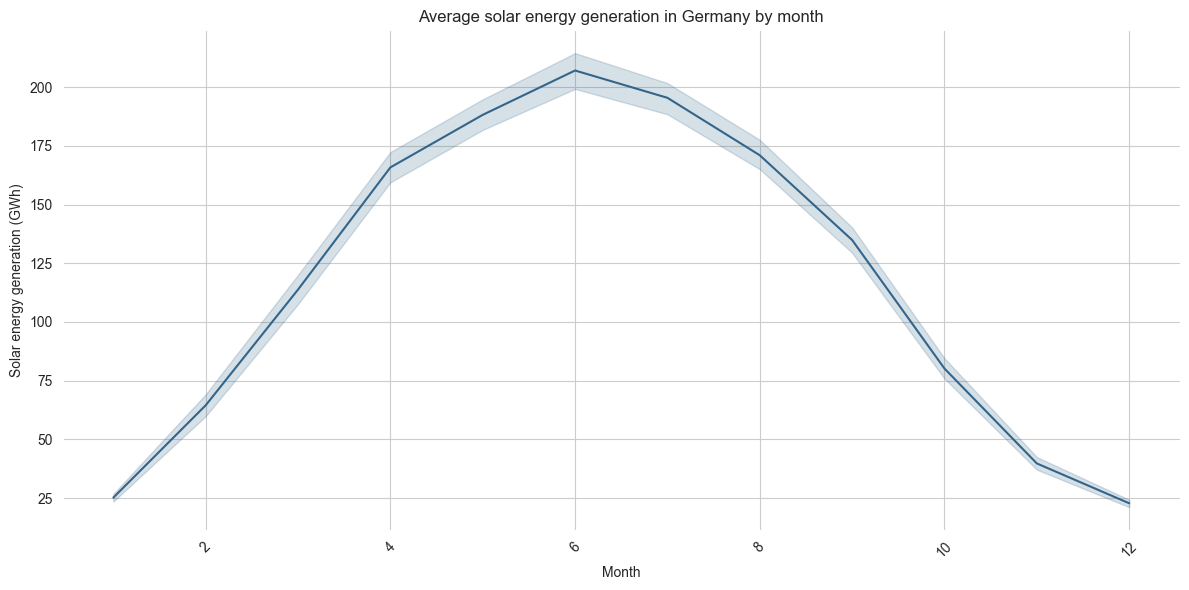

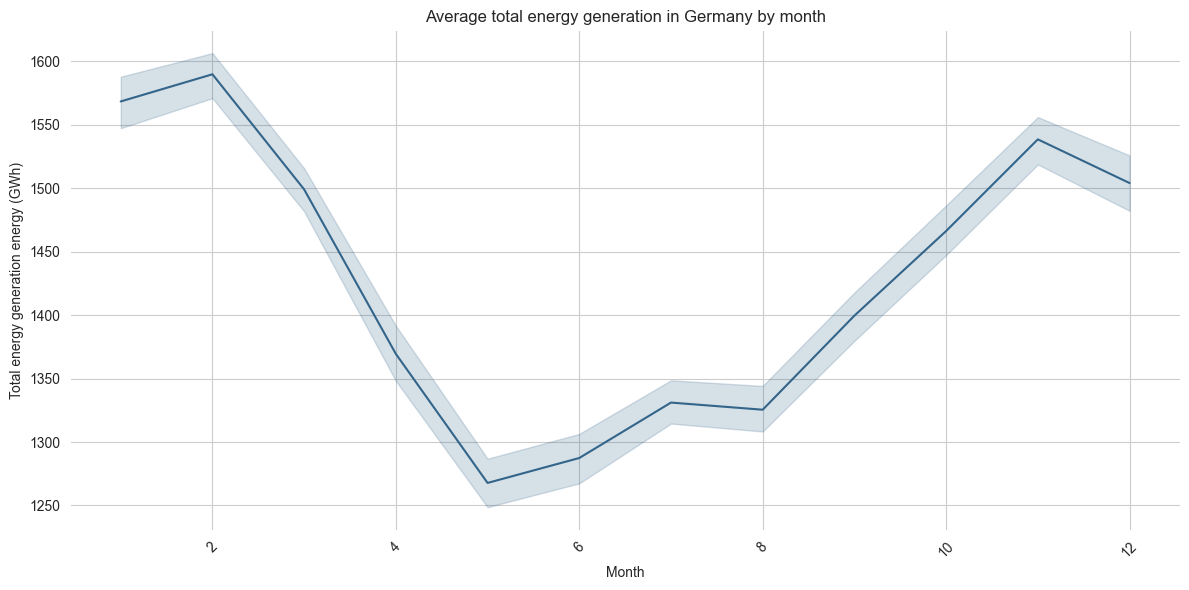

In [101]:
average_lineplot_no_group_ren(df=data_df, y='Total_other_renewable_gwh', x="Date", time='Month')
average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Month')
average_lineplot_no_group_eng(df=data_df, y= 'Total_energy_generation_gwh', x="Date", time='Month')

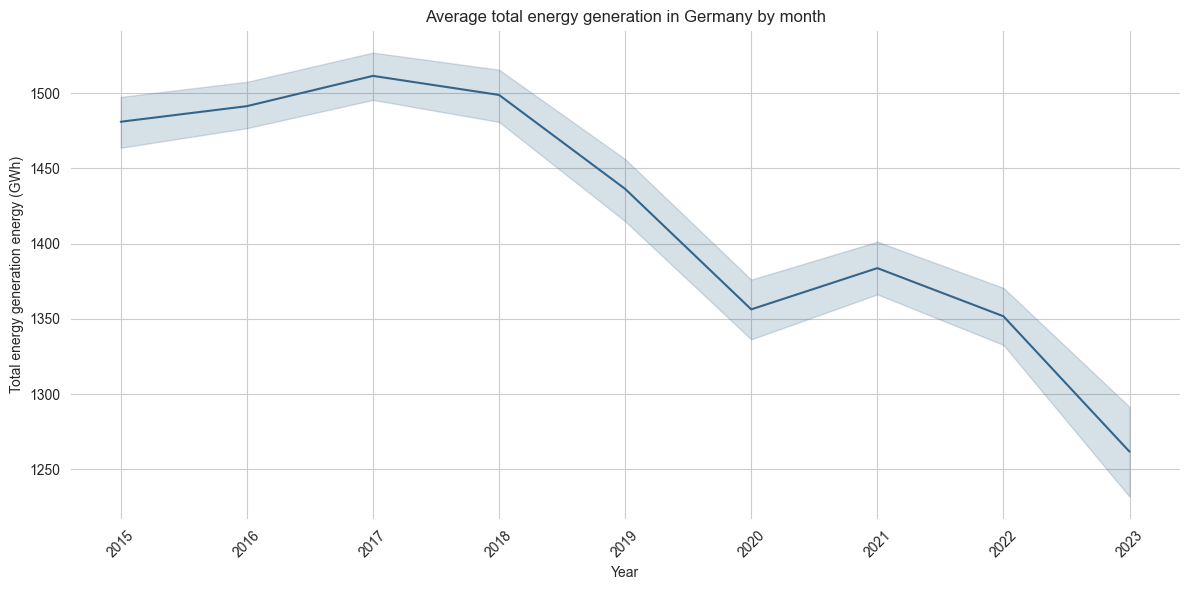

In [102]:
average_lineplot_no_group_eng(df=data_df, y= target, x="Date", time='Year')

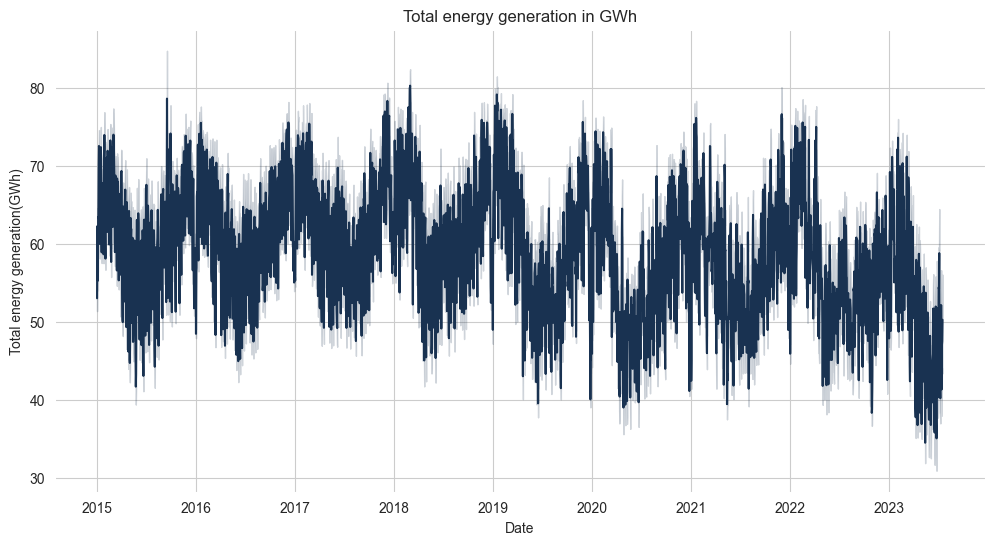

In [103]:
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

In [104]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [105]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [106]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

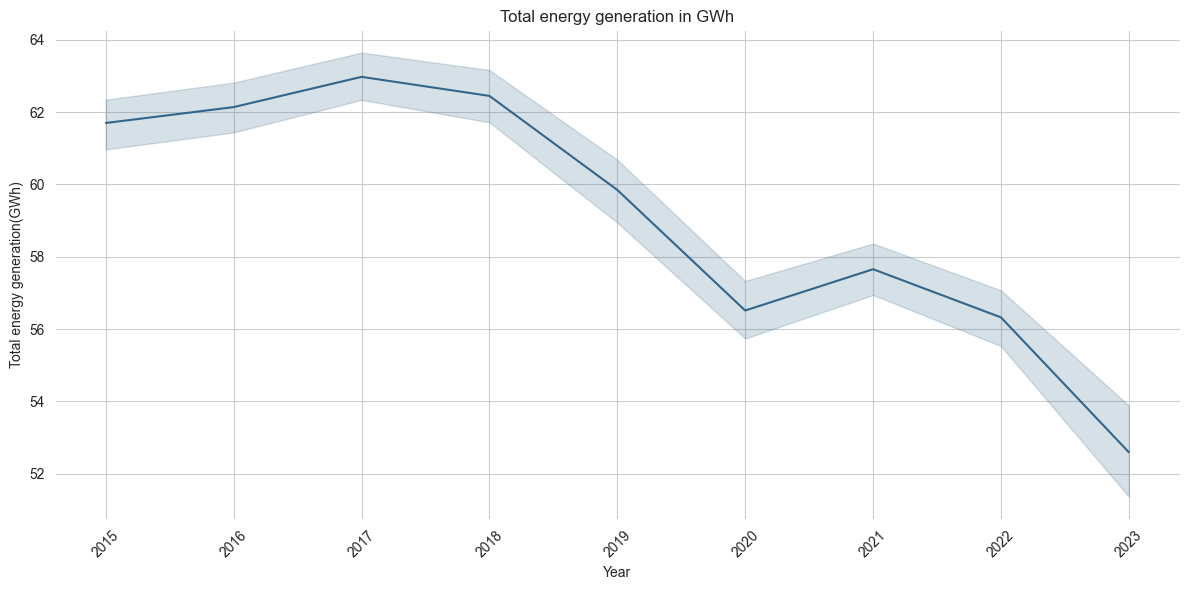

In [107]:
average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [108]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [109]:
daily_data_df, daily_data_df.columns, data_df.columns

(            Year  Month  Day  Dayofyear  Hour  Total_energy_generation_gwh
 Date                                                                      
 2015-01-01  2015      1    1          1     0                     51.45925
 2015-01-01  2015      1    1          1     1                     49.98825
 2015-01-01  2015      1    1          1     2                     49.26525
 2015-01-01  2015      1    1          1     3                     48.53800
 2015-01-01  2015      1    1          1     4                     48.63000
 ...          ...    ...  ...        ...   ...                          ...
 2023-07-17  2023      7   17        198    18                     55.58000
 2023-07-17  2023      7   17        198    19                     50.83350
 2023-07-17  2023      7   17        198    20                     46.67225
 2023-07-17  2023      7   17        198    21                     42.74150
 2023-07-17  2023      7   17        198    22                     19.82700
 
 [74871 ro

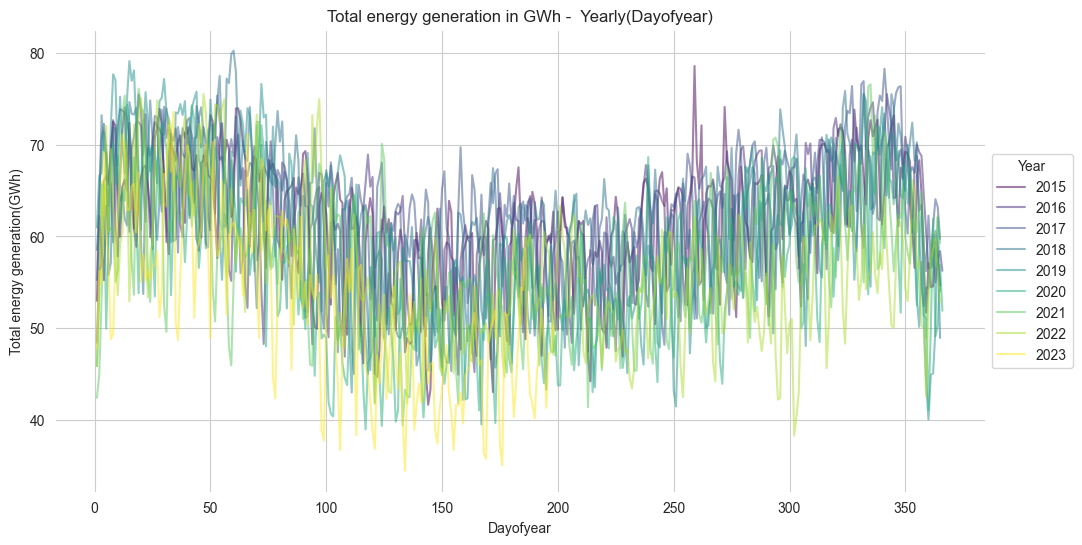

In [110]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [111]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [112]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

In [113]:
#data_df.columns

In [114]:
df_c = data_df.copy()

In [115]:
#df_c.columns

In [116]:
def combine_date_and_time(df, date_column='Date', time_column='Hour', target_column=target):
    # Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Combine 'Date' and 'Hour' columns to create the 'Datetime' column
    df['Datetime'] = df.apply(lambda row: row[date_column] + pd.Timedelta(hours=row[time_column]), axis=1)
    
    # Select the desired columns for the final DataFrame
    df_result  = df[['Datetime', target_column]]
    
    return df_result

In [117]:
df_dt = combine_date_and_time(df_c, date_column='Date', time_column='Hour', target_column=target)

#### I need to write a function to include seasonality and trend information of data 

In [118]:
# Rolling mean
# window =
#df_dt[target]=data_df[target].rolling(window=365).mean() 
#df_dt = df_dt.dropna() #df_dt = df_dt.dropna(how='all')#(axis=0)
#df_dt = df_dt.dropna(axis=0)
# Reset index after drop
#df_dt=df_dt.dropna().reset_index(drop=True)
#df_dt.head()

In [119]:
df_dt.columns

Index(['Datetime', 'Total_energy_generation_gwh'], dtype='object')

In [120]:
df_dt.head()

,Datetime,Total_energy_generation_gwh
0,2015-01-01 00:00:00,51.45925
1,2015-01-01 01:00:00,49.98825
2,2015-01-01 02:00:00,49.26525
3,2015-01-01 03:00:00,48.53800
4,2015-01-01 04:00:00,48.63000


<Axes: xlabel='Datetime'>

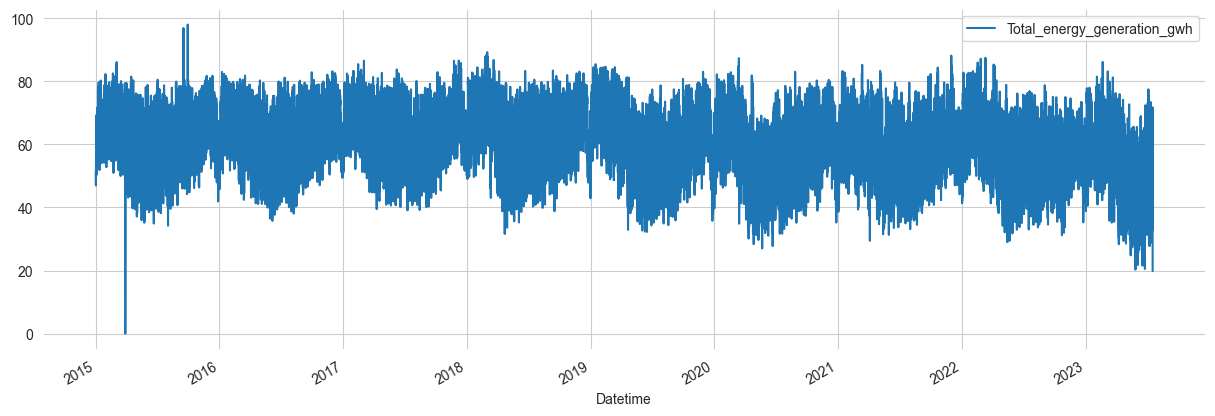

In [121]:

#df_c = data_df.copy()
#df_c = data_df[['Date',  target]]
df_dt = df_dt.set_index('Datetime')
df_dt.plot(style = '-', figsize = (15,5), color='#1f76b4')

In [122]:
#df_dt.loc[(df_dt.index > '2023-01-01') & (df_dt.index < '2023-12-01') ].plot(figsize=(15,5), ylabel=ylable_target, title= 'Data of last year', label = '2023 data')
#ax.legend(['2023 data'])
#plt.show()

In [123]:
def create_features(df):
    """
    create time series features based on time series index 
    """
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
   # df['Week'] = df.index.week
    df['Day'] = df.index.day
    #df['Dayofyear'] = df.index.dayofyear
    return df
df_dt = create_features(df_dt)
df_dt.head()

,Total_energy_generation_gwh,Hour,Year,Month,Day
Datetime,,,,,
2015-01-01 00:00:00,51.45925,0,2015,1,1
2015-01-01 01:00:00,49.98825,1,2015,1,1
2015-01-01 02:00:00,49.26525,2,2015,1,1
2015-01-01 03:00:00,48.53800,3,2015,1,1
2015-01-01 04:00:00,48.63000,4,2015,1,1


Text(0, 0.5, 'Total energy generation(GWh)')

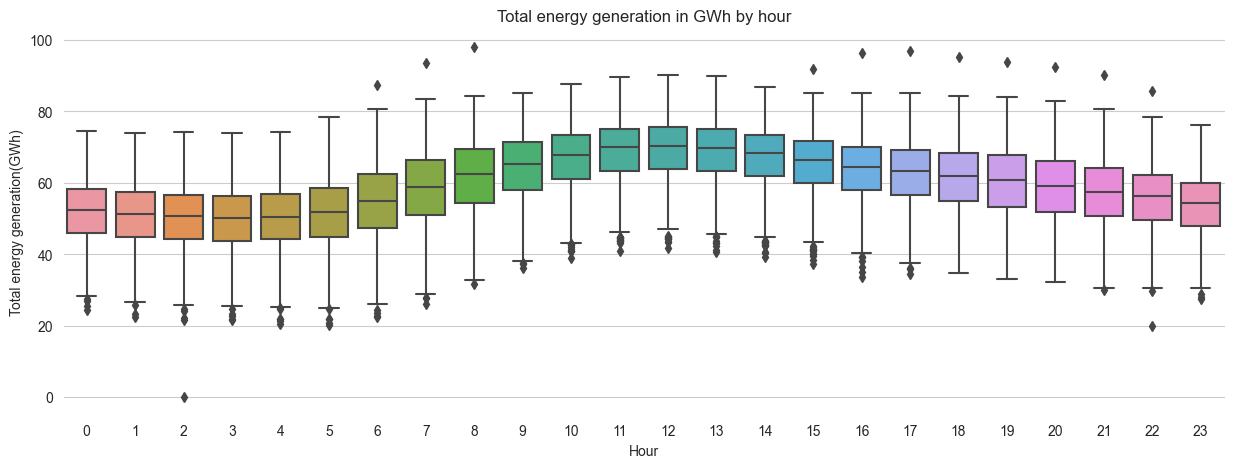

In [124]:
fig, ax = plt.subplots(figsize=(15,5))
sns.boxplot (data=df_dt, x= 'Hour', y =target)
ax.set_title( title_main + '' + ' ' 'by hour')
ax.set_ylabel(ylable_target)

In [125]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Month', y =target)
#ax.set_title(title_main + '' + ' ' 'by month')
#ax.set_ylabel(ylable_target)

In [56]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Day', y =target)
#ax.set_title(title_main + '' + ' ' 'by day')
#ax.set_ylabel(ylable_target)

## Train & Test split

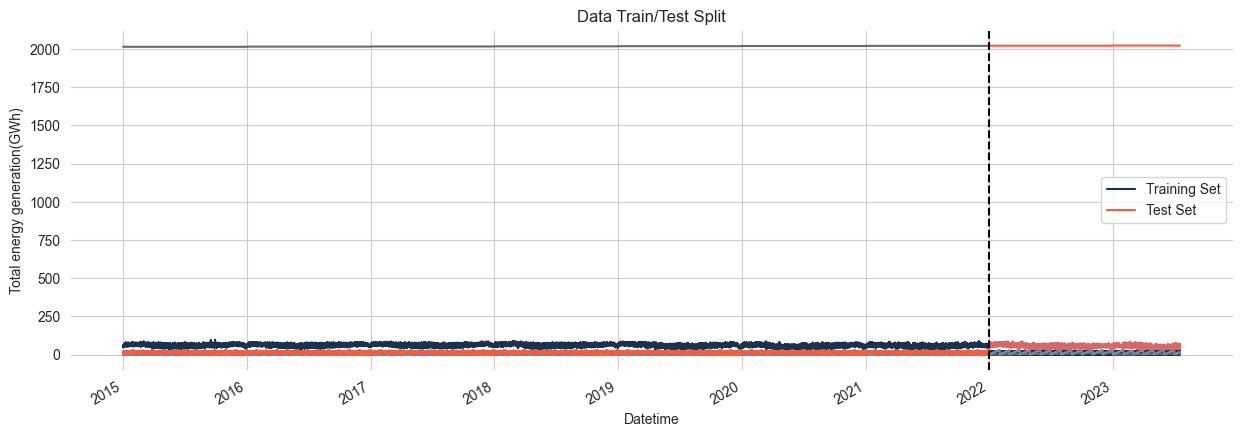

In [57]:
#df_c = pd.DataFrame(df_c.index)
#df_c.index
train =  df_dt.loc[df_dt.index < '2022-01-1']
test =  df_dt.loc[df_dt.index >= '2022-01-1']
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax, label = 'Training Set', title= 'Data Train/Test Split')
test.plot (ax=ax, ylabel=ylable_target, label = 'Test Set')
ax.axvline('2022-01-1', color = 'black', ls= '--')
ax.legend(['Training Set','Test Set'])
#ax.ylabel(target)
plt.show()

## Feature Creations

In [58]:
features= ['Hour','Year', 'Month', 'Day']# 

In [59]:
train = create_features(train)
test = create_features(test)
#train.head()

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/2334983043.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hour'] = df.index.hour
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/2334983043.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df.index.year
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/2334983043.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

### Test with XGBoost regressor 

[0]	validation_0-rmse:42.92104	validation_1-rmse:38.73085
[1]	validation_0-rmse:30.43237	validation_1-rmse:26.96369
[2]	validation_0-rmse:21.81506	validation_1-rmse:19.05868


[3]	validation_0-rmse:15.93785	validation_1-rmse:13.82733
[4]	validation_0-rmse:12.04580	validation_1-rmse:10.56970
[5]	validation_0-rmse:9.55834	validation_1-rmse:8.80807
[6]	validation_0-rmse:8.01940	validation_1-rmse:7.97804
[7]	validation_0-rmse:7.12905	validation_1-rmse:7.63841
[8]	validation_0-rmse:6.64318	validation_1-rmse:7.55762
[9]	validation_0-rmse:6.36418	validation_1-rmse:7.59266
[10]	validation_0-rmse:6.21368	validation_1-rmse:7.64953


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[11]	validation_0-rmse:6.10940	validation_1-rmse:7.71245
[12]	validation_0-rmse:5.98146	validation_1-rmse:7.83641
[13]	validation_0-rmse:5.88960	validation_1-rmse:7.89593
[14]	validation_0-rmse:5.86247	validation_1-rmse:7.92184
[15]	validation_0-rmse:5.80246	validation_1-rmse:8.00295
[16]	validation_0-rmse:5.74645	validation_1-rmse:8.02462
[17]	validation_0-rmse:5.73388	validation_1-rmse:8.04139
[18]	validation_0-rmse:5.70378	validation_1-rmse:8.07329
[19]	validation_0-rmse:5.69706	validation_1-rmse:8.08363
[20]	validation_0-rmse:5.69394	validation_1-rmse:8.08257
[21]	validation_0-rmse:5.66868	validation_1-rmse:8.13357
[22]	validation_0-rmse:5.61525	validation_1-rmse:8.21859
[23]	validation_0-rmse:5.59250	validation_1-rmse:8.22877
[24]	validation_0-rmse:5.58012	validation_1-rmse:8.22855
[25]	validation_0-rmse:5.54589	validation_1-rmse:8.23066
[26]	validation_0-rmse:5.52486	validation_1-rmse:8.24557
[27]	validation_0-rmse:5.49052	validation_1-rmse:8.29022
[28]	validation_0-rmse:5.45494	

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/957641043.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = xgb_reg.predict(X_test)


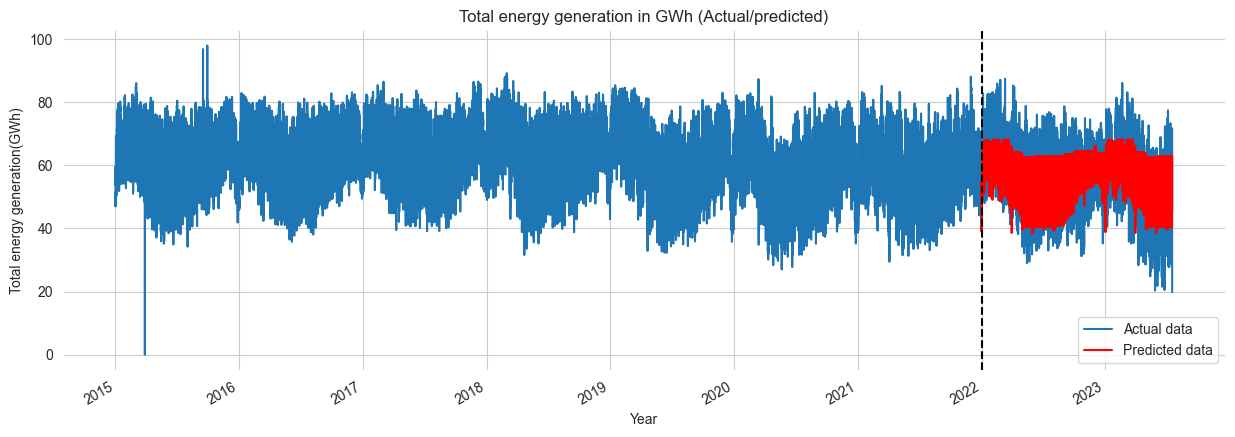

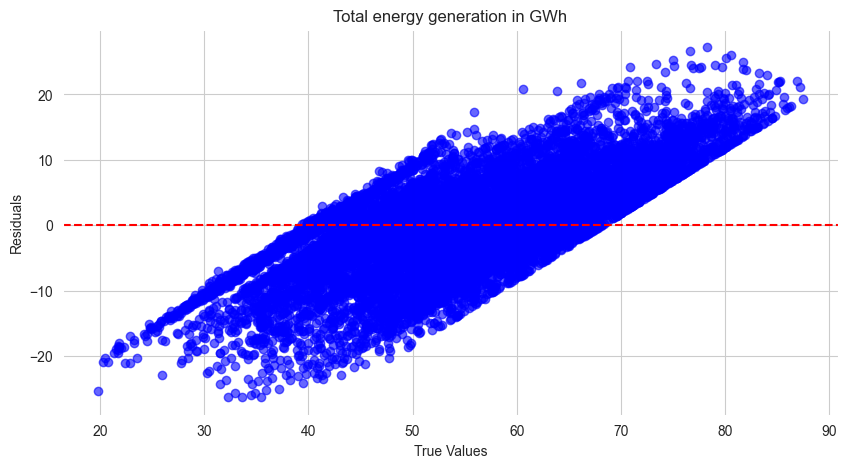

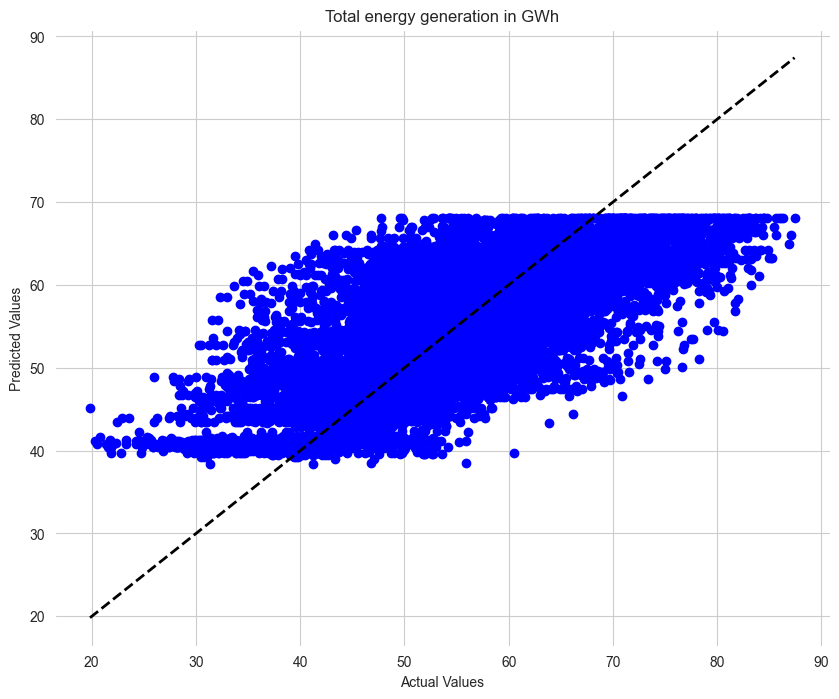

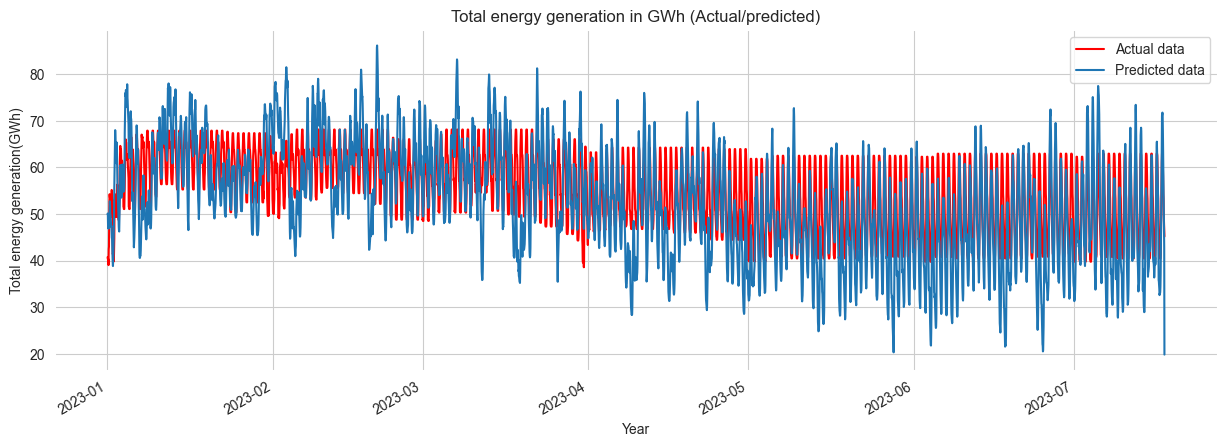

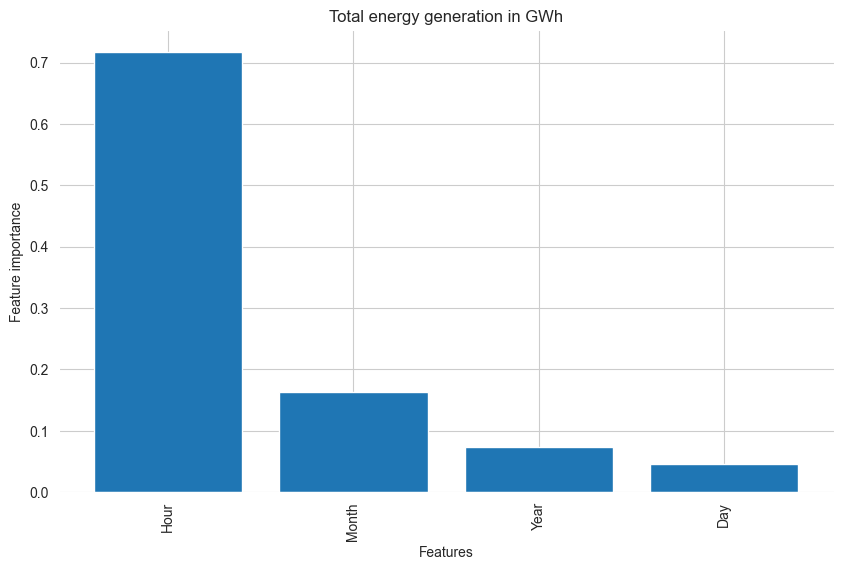

In [60]:
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]
xgb_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42)
xgb_reg.fit(X_train, y_train, eval_set = [(X_train, y_train),(X_test, y_test)],early_stopping_rounds=50 ,verbose =True )

test['prediction'] = xgb_reg.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot (ax=ax,   color='#1f76b4', label = 'actual data')
test['prediction'].plot(ax=ax, color='red',  label = 'predicted data', title= title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color = 'black',label = 'test/train split',  ls= '--')
ax.legend(['Actual data','Predicted data'])
#ax.set_title(title_main + '' + ' ' 'by day')
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-31') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-31') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()



# Get the feature importances
importances = xgb_reg.feature_importances_
# Create a list of feature names
feature_names = X_train.columns
# Sort feature importances in descending order
indices = importances.argsort()[::-1]
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title(title_main)
plt.show()

#### Grid Search  for XGBRegressor (unscale data)

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in 

Best parameters found during grid search: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Mean Squared Error (MSE): 56.54364545072283
Mean Absolute Error (MAE): 5.963931286630129
R-squared (R2): 0.567680616597479
Root Mean Squared Error (RMSE): 7.519550880918542


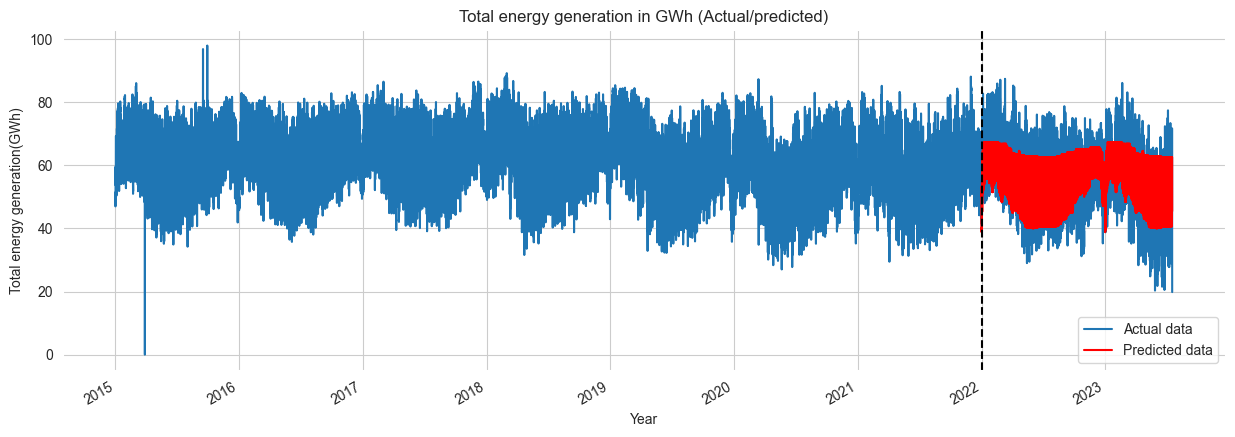

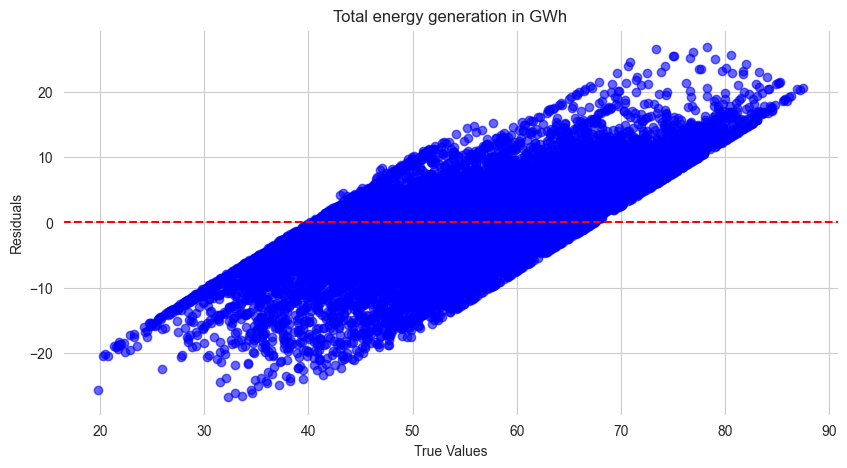

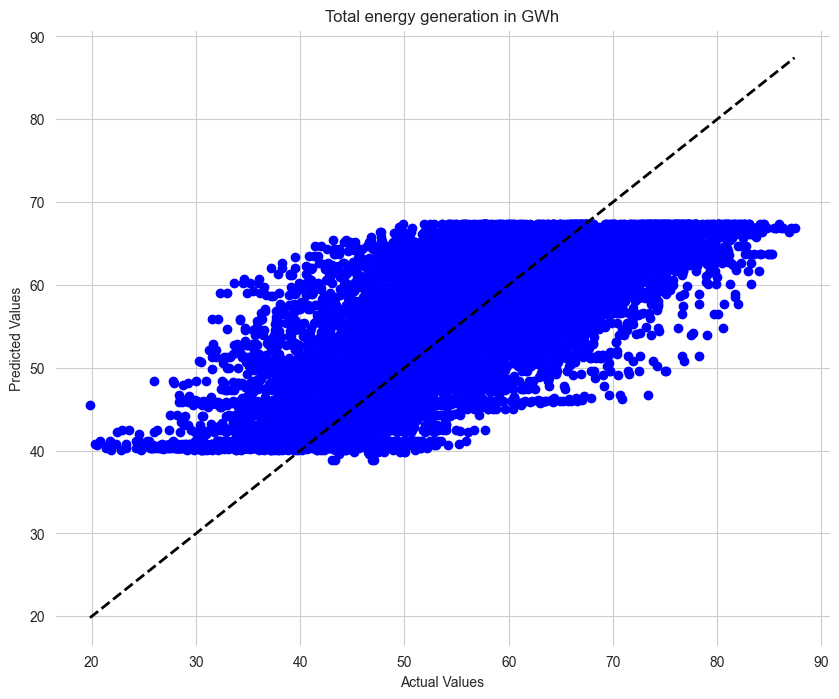

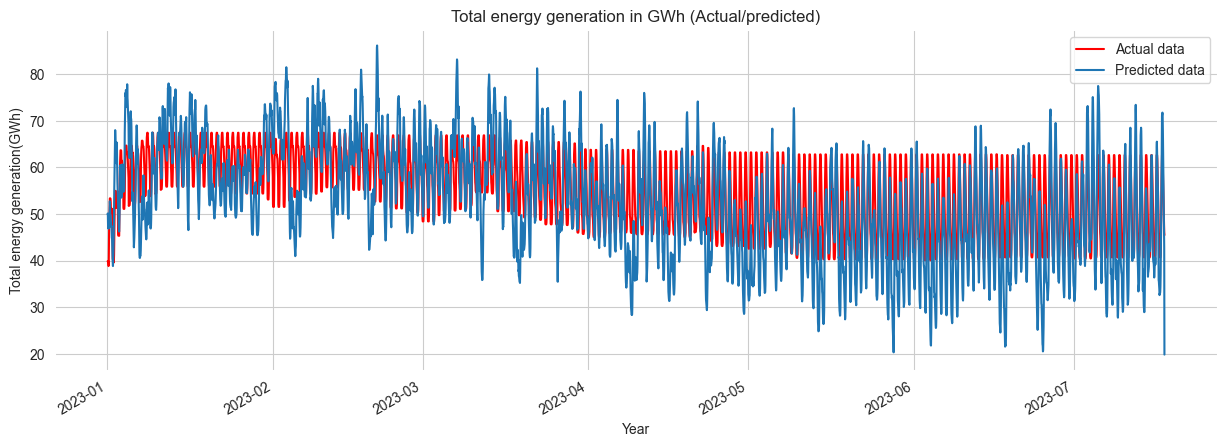

In [629]:
from sklearn.model_selection import GridSearchCV

X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create an XGBoost regressor
xgb_reg = xgb.XGBRegressor()

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 500, 1000],   # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7],             # Maximum depth of a tree
    'subsample': [0.8, 1.0],            # Subsample ratio of the training instances
    'colsample_bytree': [0.8, 1.0]      # Subsample ratio of columns when constructing each tree
}

# Create GridSearchCV with the XGBoost regressor and parameter grid
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)

# Perform the grid search on the training data
grid_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50, verbose=False)

# Get the best model from the grid search
best_xgb_reg = grid_search.best_estimator_

# Make predictions on the test set using the best model
test['prediction'] = best_xgb_reg.predict(X_test)


# Calculate evaluation metrics for the best model
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
r2 = r2_score(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)


print("Best parameters found during grid search:", grid_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)
print("Root Mean Squared Error (RMSE):", rmse)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot (ax=ax,   color='#1f76b4', label = 'actual data')
test['prediction'].plot(ax=ax, color='red',  label = 'predicted data', title= title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color = 'black',label = 'test/train split',  ls= '--')
ax.legend(['Actual data','Predicted data'])
#ax.set_title(title_main + '' + ' ' 'by day')
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()



#### RandomizedSearchCV for XGBRegressor (unscale)

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in 

Best parameters found during random search: {'colsample_bytree': 1.0, 'learning_rate': 0.05655426808606085, 'max_depth': 5, 'n_estimators': 975, 'subsample': 0.8}
Mean Squared Error (MSE): 56.54867877938222
Mean Absolute Error (MAE): 5.965121674123859
Root Mean Squared Error (RMSE): 7.51988555626894
R-squared (R2): 0.5676421329531164


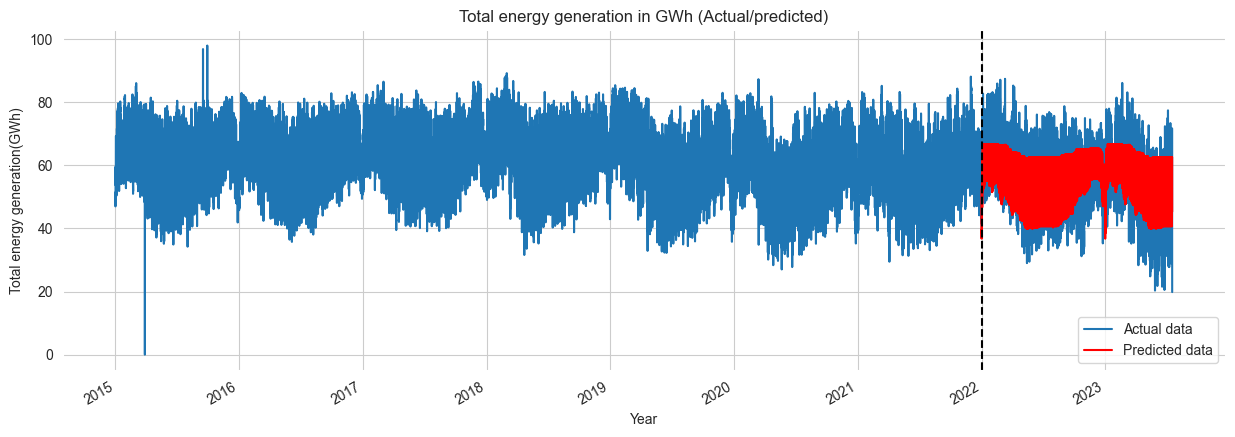

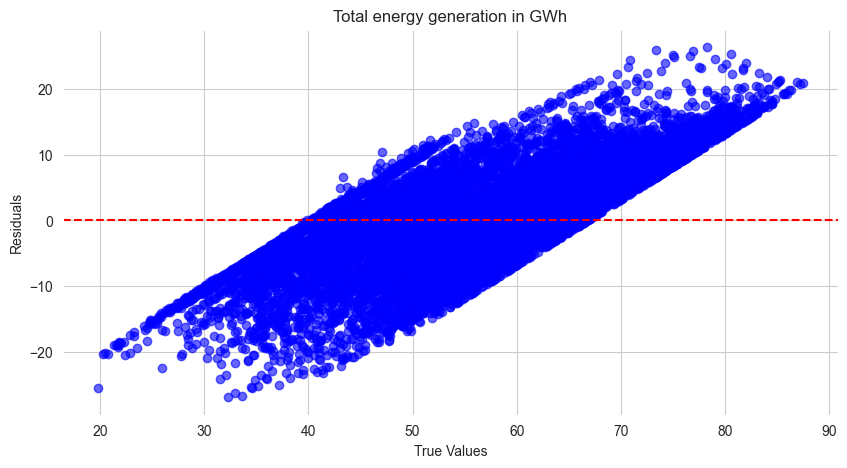

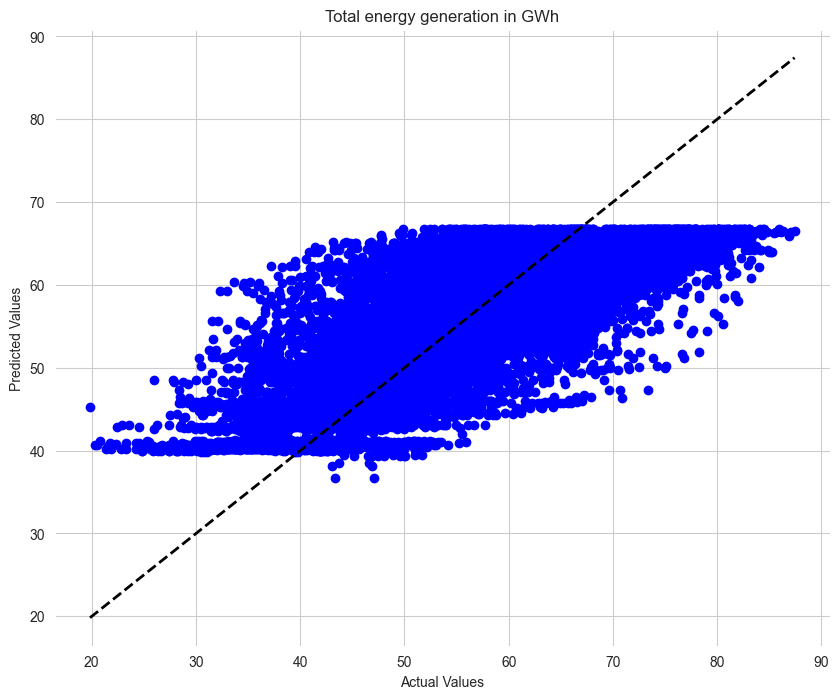

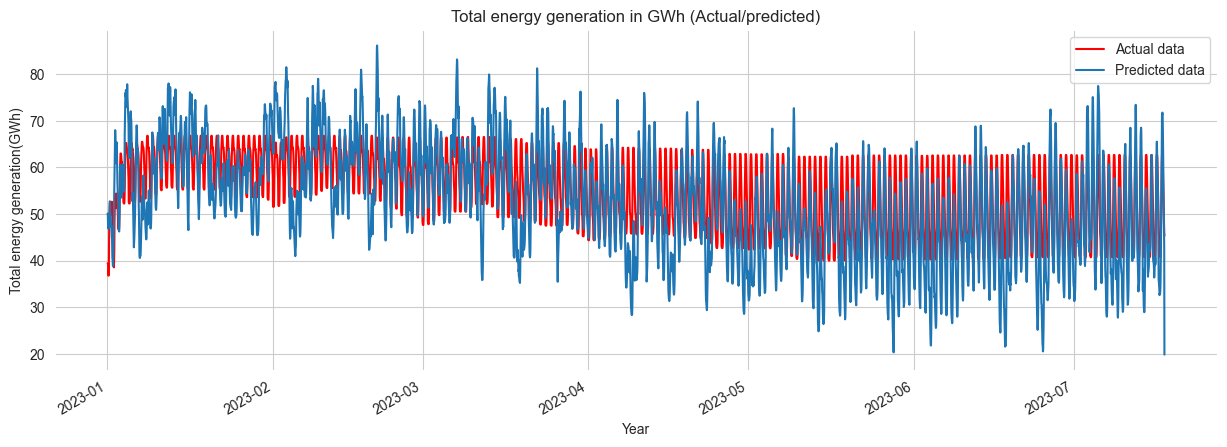

In [630]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
# Assuming you have already defined the variables X_train, X_test, y_train, y_test as mentioned in the question.
# Create an XGBoost regressor

X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

xgb_reg = xgb.XGBRegressor()

# Define the parameter distribution to search
param_dist = {
    'n_estimators': randint(100, 1001),   # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.2),  # Step size shrinkage to prevent overfitting
    'max_depth': randint(3, 8),           # Maximum depth of a tree
    'subsample': [0.8, 1.0],              # Subsample ratio of the training instances
    'colsample_bytree': [0.8, 1.0]        # Subsample ratio of columns when constructing each tree
}

# Create RandomizedSearchCV with the XGBoost regressor and parameter distribution
random_search = RandomizedSearchCV(estimator=xgb_reg, param_distributions=param_dist, scoring='neg_mean_squared_error', cv=5, n_iter=10, random_state=42)

# Perform the randomized grid search on the training data
random_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50, verbose=False)

# Get the best model from the random search
best_xgb_reg = random_search.best_estimator_

# Make predictions on the test set using the best model
test['prediction'] = best_xgb_reg.predict(X_test)

# Calculate evaluation metrics for the best model
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Best parameters found during random search:", random_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)


# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot (ax=ax,   color='#1f76b4', label = 'actual data')
test['prediction'].plot(ax=ax, color='red',  label = 'predicted data', title= title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color = 'black',label = 'test/train split',  ls= '--')
ax.legend(['Actual data','Predicted data'])
#ax.set_title(title_main + '' + ' ' 'by day')
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()







#### XGboost with  StandardScaler()

[0]	validation_0-rmse:42.91320	validation_1-rmse:38.68646
[1]	validation_0-rmse:30.40255	validation_1-rmse:26.83352
[2]	validation_0-rmse:21.76325	validation_1-rmse:18.94436
[3]	validation_0-rmse:15.86936	validation_1-rmse:13.75001
[4]	validation_0-rmse:11.94963	validation_1-rmse:10.56295
[5]	validation_0-rmse:9.41567	validation_1-rmse:8.81240
[6]	validation_0-rmse:7.86333	validation_1-rmse:7.98260
[7]	validation_0-rmse:6.95723	validation_1-rmse:7.64353
[8]	validation_0-rmse:6.44764	validation_1-rmse:7.57795
[9]	validation_0-rmse:6.17730	validation_1-rmse:7.61298
[10]	validation_0-rmse:6.01532	validation_1-rmse:7.68324
[11]	validation_0-rmse:5.91455	validation_1-rmse:7.76911
[12]	validation_0-rmse:5.85589	validation_1-rmse:7.80882
[13]	validation_0-rmse:5.81651	validation_1-rmse:7.84842
[14]	validation_0-rmse:5.77250	validation_1-rmse:7.86710
[15]	validation_0-rmse:5.73837	validation_1-rmse:7.90712
[16]	validation_0-rmse:5.72047	validation_1-rmse:7.93374


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[17]	validation_0-rmse:5.63321	validation_1-rmse:8.00878
[18]	validation_0-rmse:5.62382	validation_1-rmse:8.01310
[19]	validation_0-rmse:5.55531	validation_1-rmse:8.11142
[20]	validation_0-rmse:5.49046	validation_1-rmse:8.15492
[21]	validation_0-rmse:5.45873	validation_1-rmse:8.18175
[22]	validation_0-rmse:5.40956	validation_1-rmse:8.23771
[23]	validation_0-rmse:5.36112	validation_1-rmse:8.34216
[24]	validation_0-rmse:5.33596	validation_1-rmse:8.34587
[25]	validation_0-rmse:5.30009	validation_1-rmse:8.33389
[26]	validation_0-rmse:5.26343	validation_1-rmse:8.35235
[27]	validation_0-rmse:5.25724	validation_1-rmse:8.35390
[28]	validation_0-rmse:5.23385	validation_1-rmse:8.37699
[29]	validation_0-rmse:5.21332	validation_1-rmse:8.39774
[30]	validation_0-rmse:5.20327	validation_1-rmse:8.39566
[31]	validation_0-rmse:5.19759	validation_1-rmse:8.39566
[32]	validation_0-rmse:5.18993	validation_1-rmse:8.39557
[33]	validation_0-rmse:5.16747	validation_1-rmse:8.41099
[34]	validation_0-rmse:5.16082	

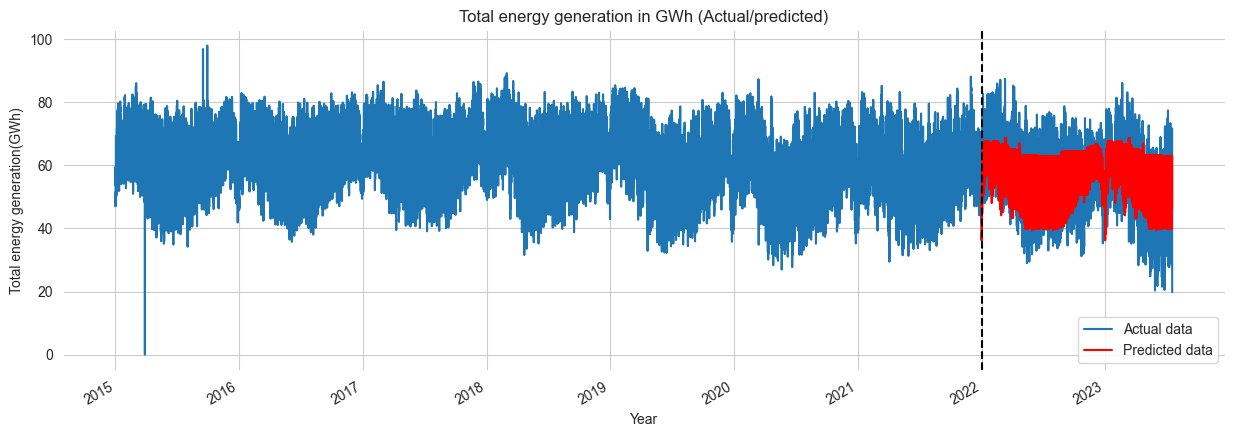

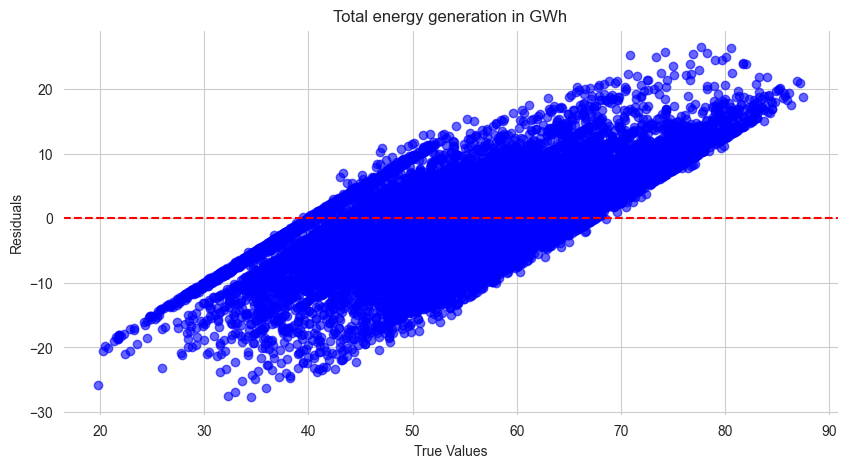

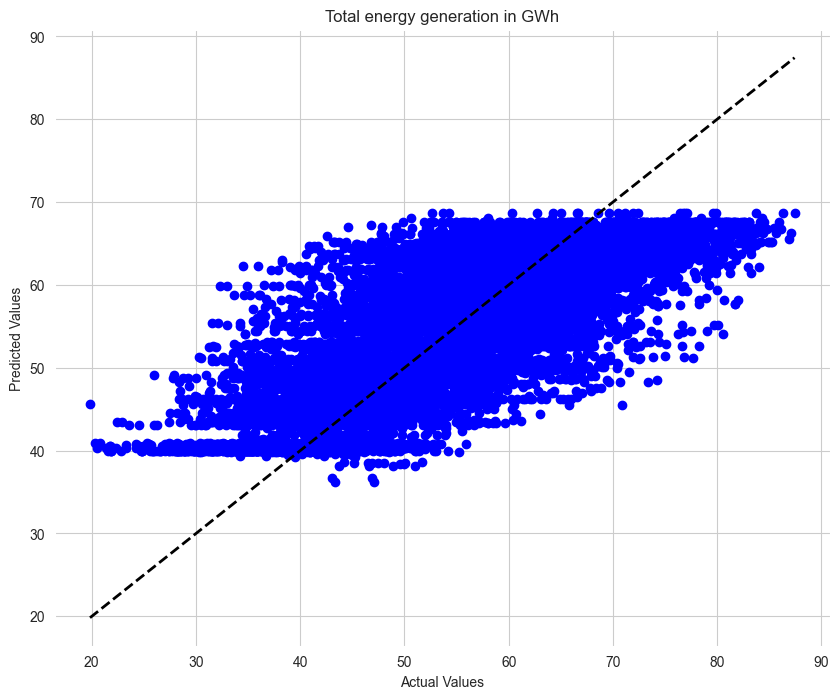

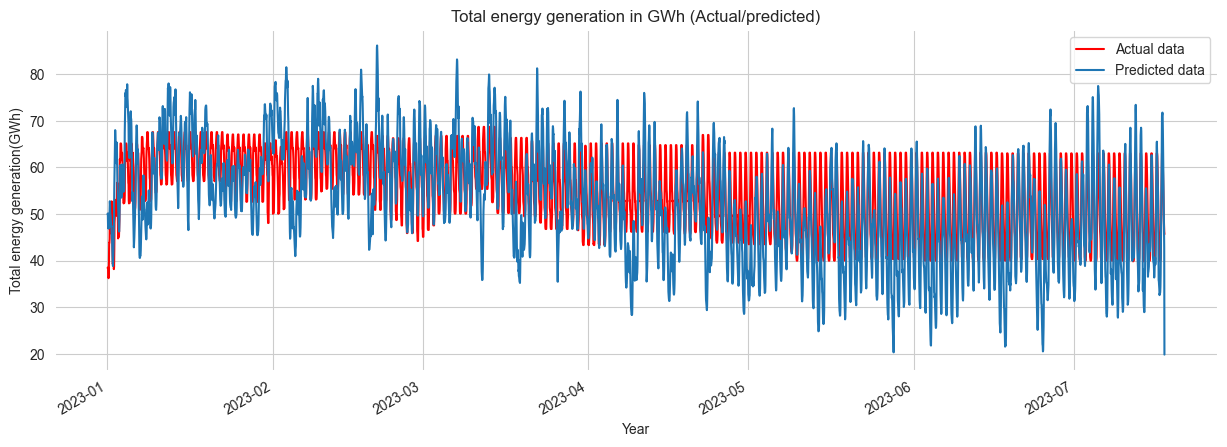

In [631]:
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create a StandardScaler object
scaler = StandardScaler()
# Scale the features separately for training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create an XGBoost regressor
xgb_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42)

# Fit the model on the scaled training data
xgb_reg.fit(X_train_scaled, y_train, eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)], early_stopping_rounds=50, verbose=True)

# Make predictions on the test set using the fitted model
test['prediction'] = xgb_reg.predict(X_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot (ax=ax,   color='#1f76b4', label = 'actual data')
test['prediction'].plot(ax=ax, color='red',  label = 'predicted data', title= title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color = 'black',label = 'test/train split',  ls= '--')
ax.legend(['Actual data','Predicted data'])
#ax.set_title(title_main + '' + ' ' 'by day')
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()


#### Feature importance plot

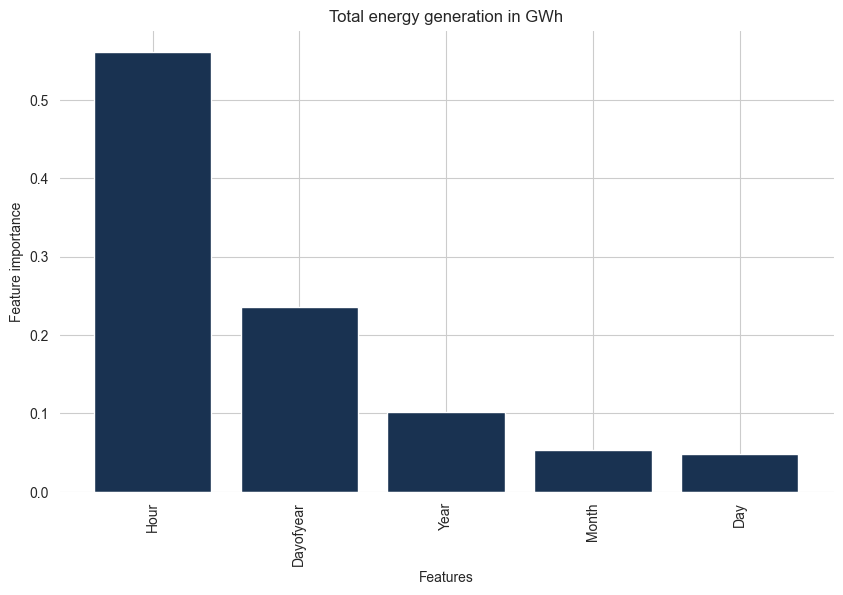

In [632]:
# Get the feature importances
importances = xgb_reg.feature_importances_
# Create a list of feature names
feature_names = X_train.columns
# Sort feature importances in descending order
indices = importances.argsort()[::-1]
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title(title_main)
plt.show()



#### XGboost with  StandardScaler()

[0]	validation_0-rmse:42.91320	validation_1-rmse:38.68646
[1]	validation_0-rmse:30.40255	validation_1-rmse:26.83352
[2]	validation_0-rmse:21.76325	validation_1-rmse:18.94436
[3]	validation_0-rmse:15.86936	validation_1-rmse:13.75001
[4]	validation_0-rmse:11.94963	validation_1-rmse:10.56295
[5]	validation_0-rmse:9.41567	validation_1-rmse:8.81240
[6]	validation_0-rmse:7.86333	validation_1-rmse:7.98260
[7]	validation_0-rmse:6.95723	validation_1-rmse:7.64353
[8]	validation_0-rmse:6.44764	validation_1-rmse:7.57795
[9]	validation_0-rmse:6.17730	validation_1-rmse:7.61298
[10]	validation_0-rmse:6.01532	validation_1-rmse:7.68324
[11]	validation_0-rmse:5.91455	validation_1-rmse:7.76911
[12]	validation_0-rmse:5.85589	validation_1-rmse:7.80882
[13]	validation_0-rmse:5.81651	validation_1-rmse:7.84842


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[14]	validation_0-rmse:5.77250	validation_1-rmse:7.86710
[15]	validation_0-rmse:5.73837	validation_1-rmse:7.90712
[16]	validation_0-rmse:5.72047	validation_1-rmse:7.93374
[17]	validation_0-rmse:5.63321	validation_1-rmse:8.00878
[18]	validation_0-rmse:5.62382	validation_1-rmse:8.01310
[19]	validation_0-rmse:5.55531	validation_1-rmse:8.11142
[20]	validation_0-rmse:5.49046	validation_1-rmse:8.15492
[21]	validation_0-rmse:5.45873	validation_1-rmse:8.18175
[22]	validation_0-rmse:5.40956	validation_1-rmse:8.23771
[23]	validation_0-rmse:5.36112	validation_1-rmse:8.34216
[24]	validation_0-rmse:5.33596	validation_1-rmse:8.34587
[25]	validation_0-rmse:5.30009	validation_1-rmse:8.33389
[26]	validation_0-rmse:5.26343	validation_1-rmse:8.35235
[27]	validation_0-rmse:5.25724	validation_1-rmse:8.35390
[28]	validation_0-rmse:5.23385	validation_1-rmse:8.37699
[29]	validation_0-rmse:5.21332	validation_1-rmse:8.39774
[30]	validation_0-rmse:5.20327	validation_1-rmse:8.39566
[31]	validation_0-rmse:5.19759	

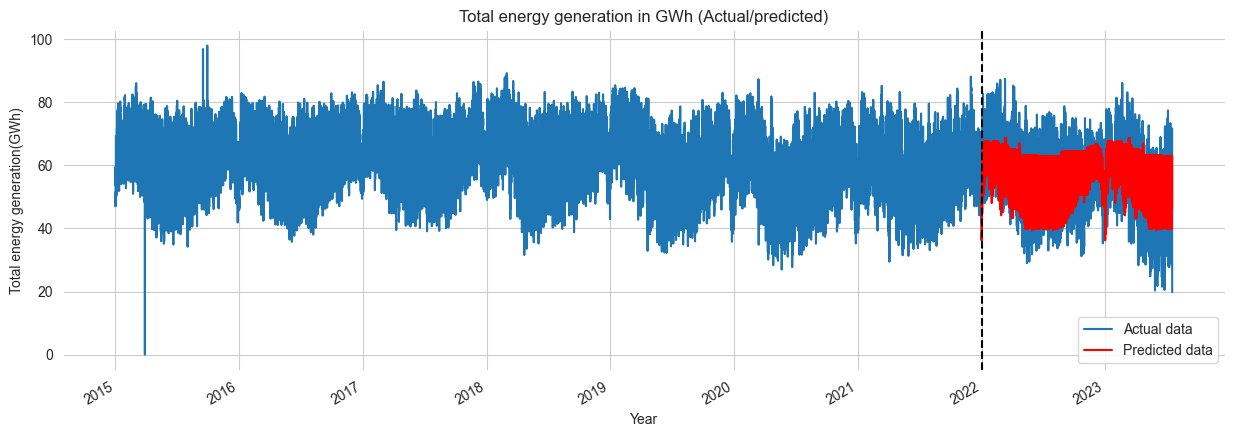

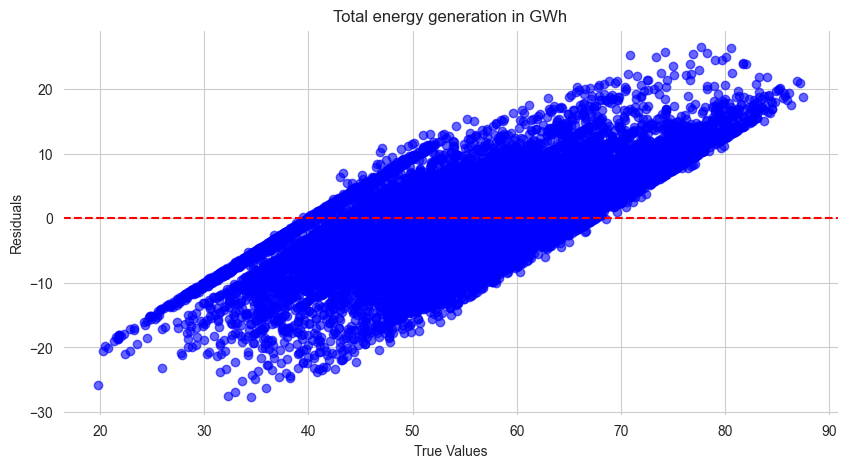

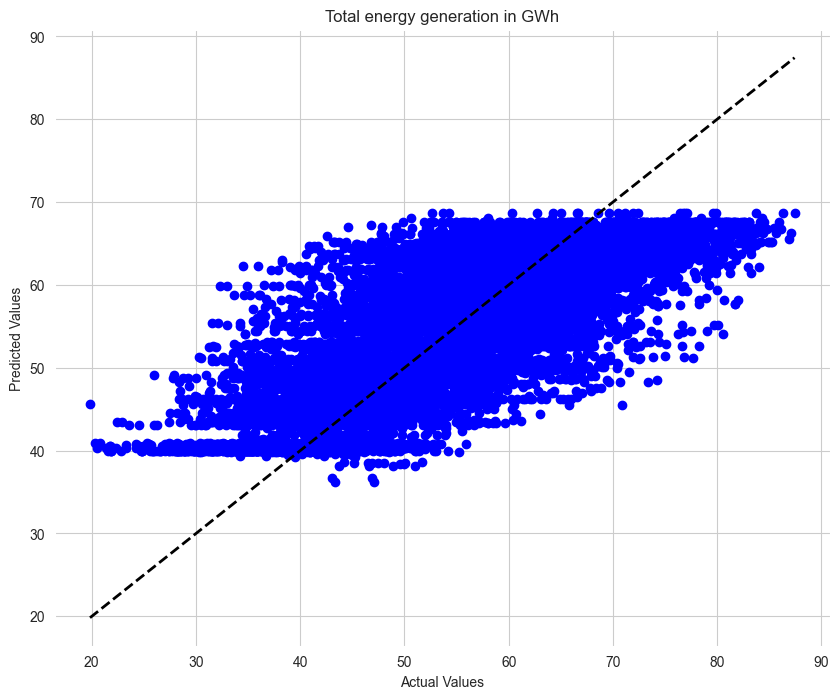

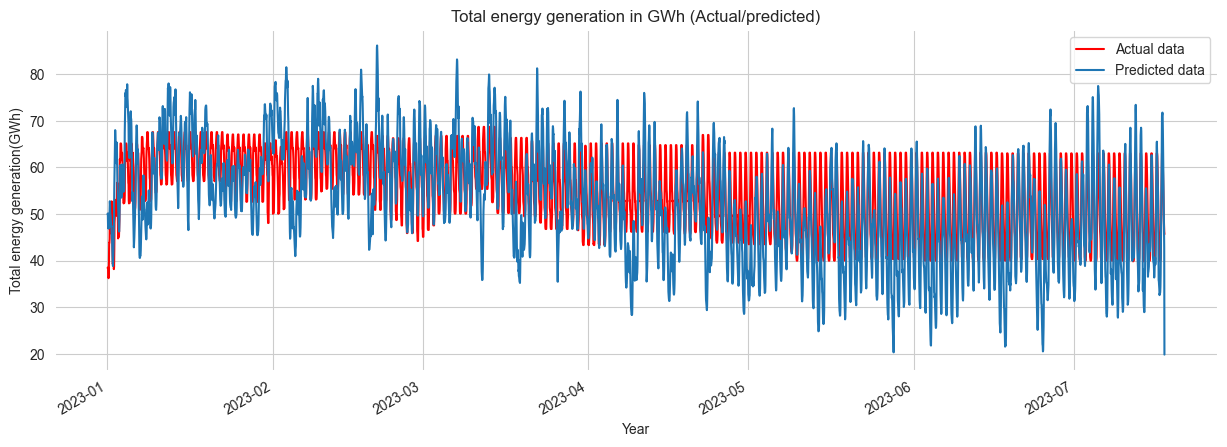

In [633]:
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Scale the features separately for training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create an XGBoost regressor
xgb_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42)

# Fit the model on the scaled training data
xgb_reg.fit(X_train_scaled, y_train, eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)], early_stopping_rounds=50, verbose=True)

# Make predictions on the test set using the fitted model
test['prediction'] = xgb_reg.predict(X_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label='', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in 

Best parameters found during random search: {'colsample_bytree': 1.0, 'learning_rate': 0.05655426808606085, 'max_depth': 5, 'n_estimators': 975, 'subsample': 0.8}
Mean Squared Error (MSE): 56.54867877938222
Mean Absolute Error (MAE): 5.965121674123859
Root Mean Squared Error (RMSE): 7.51988555626894
R-squared (R2): 0.5676421329531164


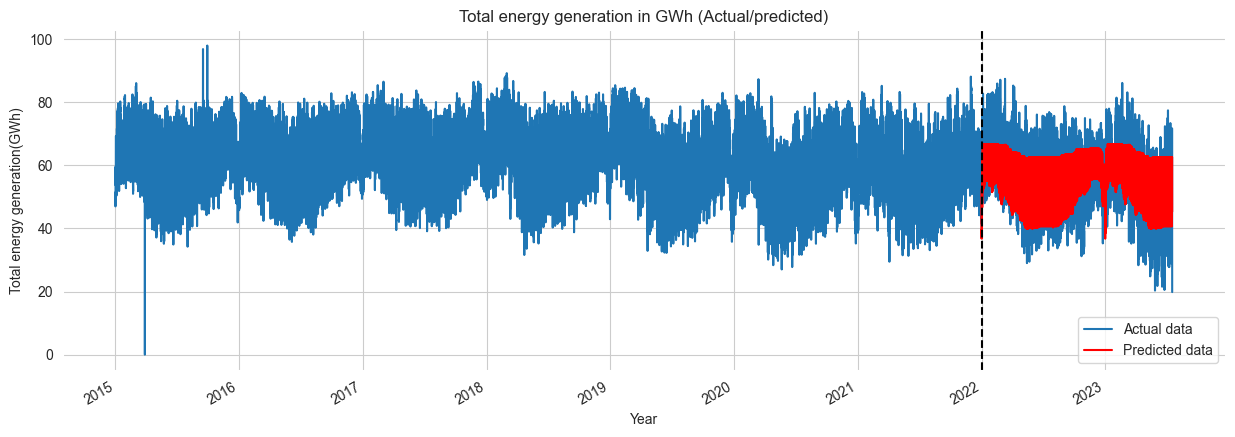

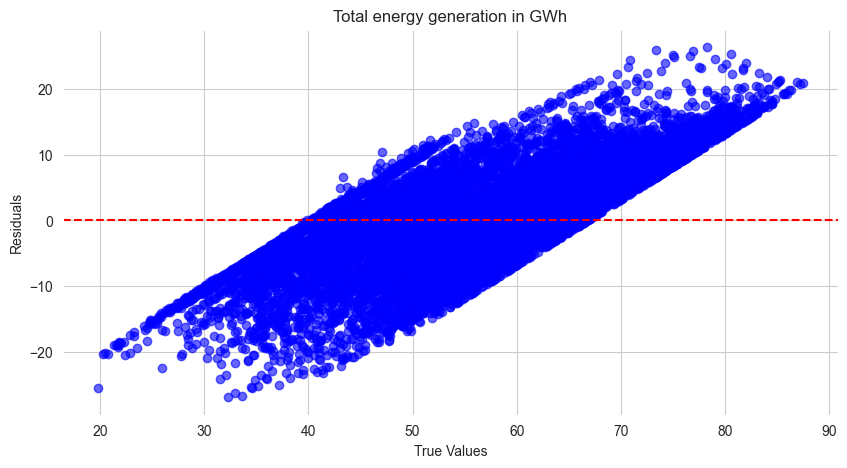

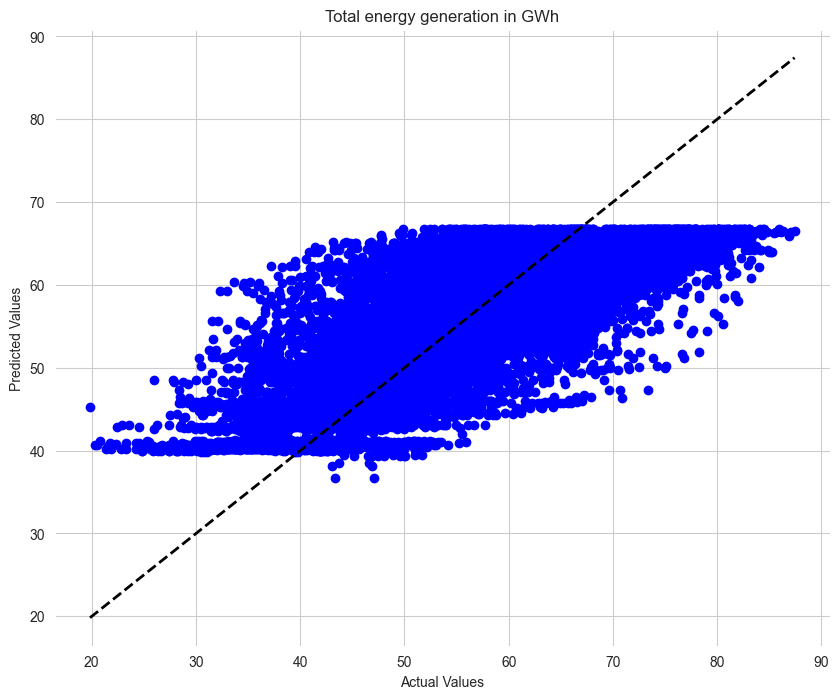

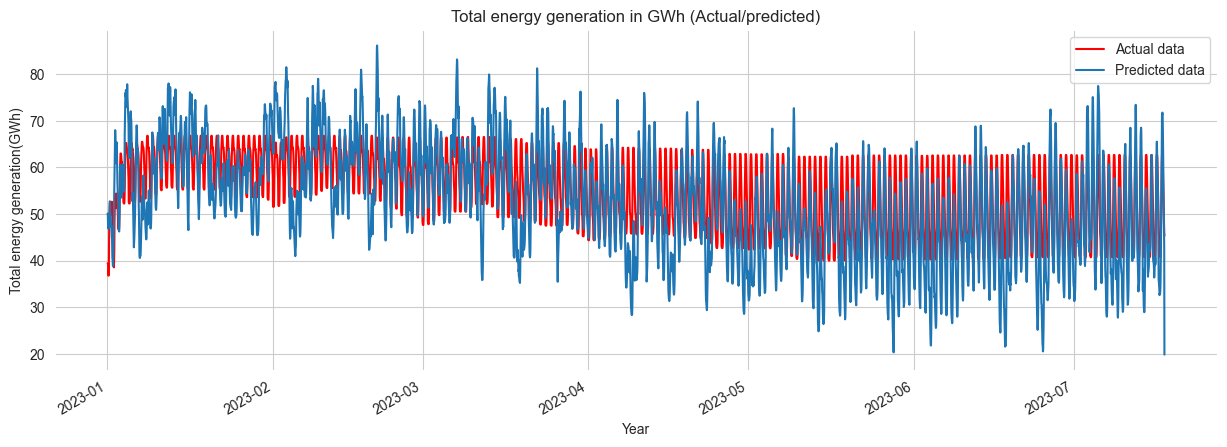

In [634]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]


# Create an XGBoost regressor
xgb_reg = xgb.XGBRegressor()

# Define the parameter distribution to search
param_dist = {
    'n_estimators': randint(100, 1001),   # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.2),  # Step size shrinkage to prevent overfitting
    'max_depth': randint(3, 8),           # Maximum depth of a tree
    'subsample': [0.8, 1.0],              # Subsample ratio of the training instances
    'colsample_bytree': [0.8, 1.0]        # Subsample ratio of columns when constructing each tree
}

# Create RandomizedSearchCV with the XGBoost regressor and parameter distribution
random_search = RandomizedSearchCV(estimator=xgb_reg, param_distributions=param_dist, scoring='neg_mean_squared_error', cv=5, n_iter=10, random_state=42)

# Perform the randomized grid search on the training data
random_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50, verbose=False)

# Get the best model from the random search
best_xgb_reg = random_search.best_estimator_

# Make predictions on the test set using the best model
test['prediction'] = best_xgb_reg.predict(X_test)

# Calculate evaluation metrics for the best model
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Best parameters found during random search:", random_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot (ax=ax,   color='#1f76b4', label = 'actual data')
test['prediction'].plot(ax=ax, color='red',  label = 'predicted data', title= title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color = 'black',label = 'test/train split',  ls= '--')
ax.legend(['Actual data','Predicted data'])
#ax.set_title(title_main + '' + ' ' 'by day')
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()


## RandomForestRegressor (Unscale date)

Mean Squared Error (MSE): 94.89885834438942
Mean Absolute Error (MAE): 7.5976224480247145
Root Mean Squared Error (RMSE): 9.741604505644306
R-squared (R2): 0.2744257007482146


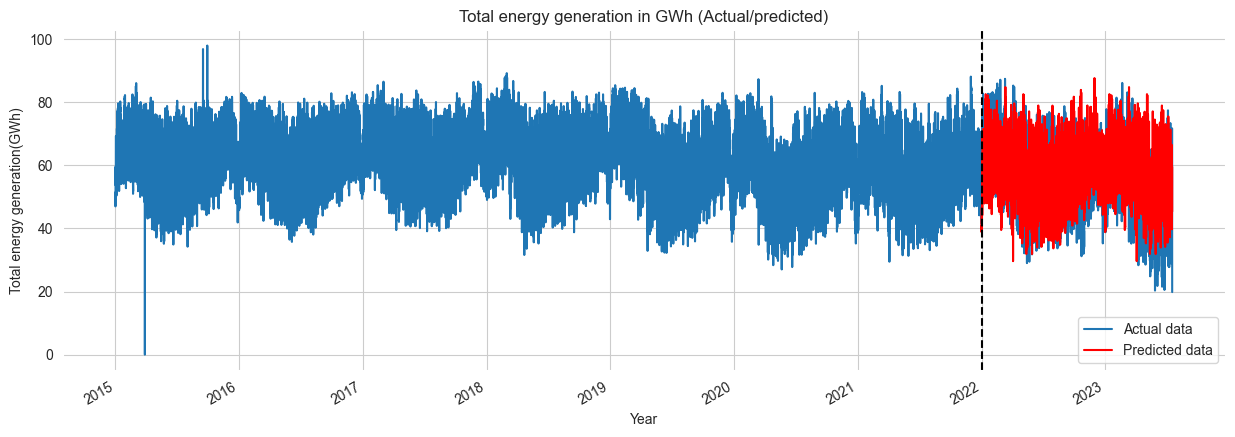

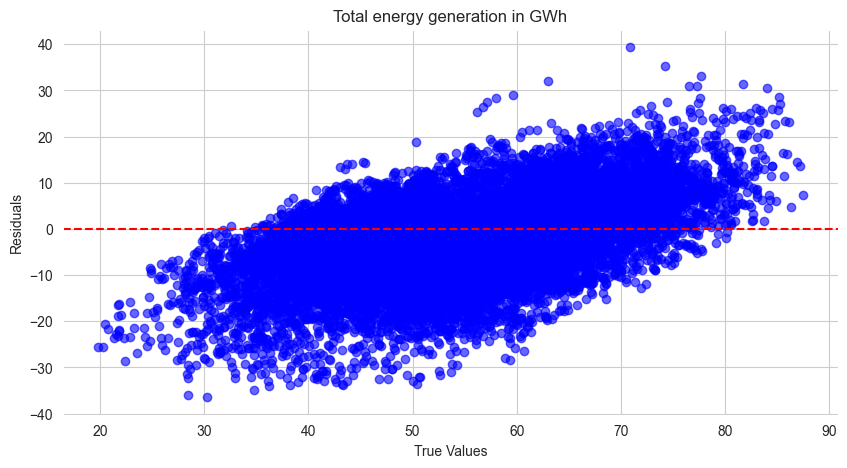

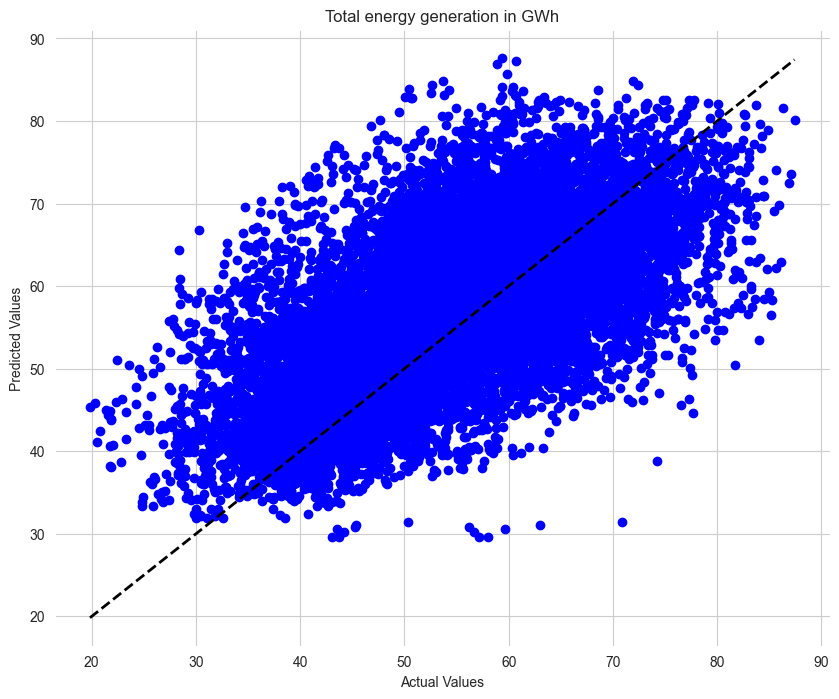

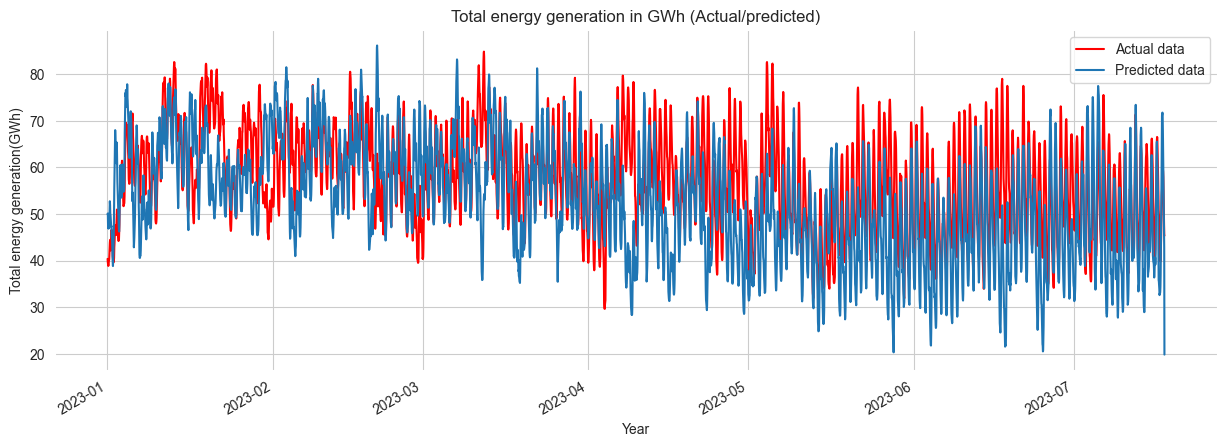

In [635]:
# for unscale data
X_train= train[features]
X_test= test[features]
y_train = train[target]
y_test = test[target]

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=1000, random_state=42)

# Fit the model on the training data
rf_reg.fit(X_train, y_train)

# Make predictions on the test set
test['prediction'] = rf_reg.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

# zoom view
fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

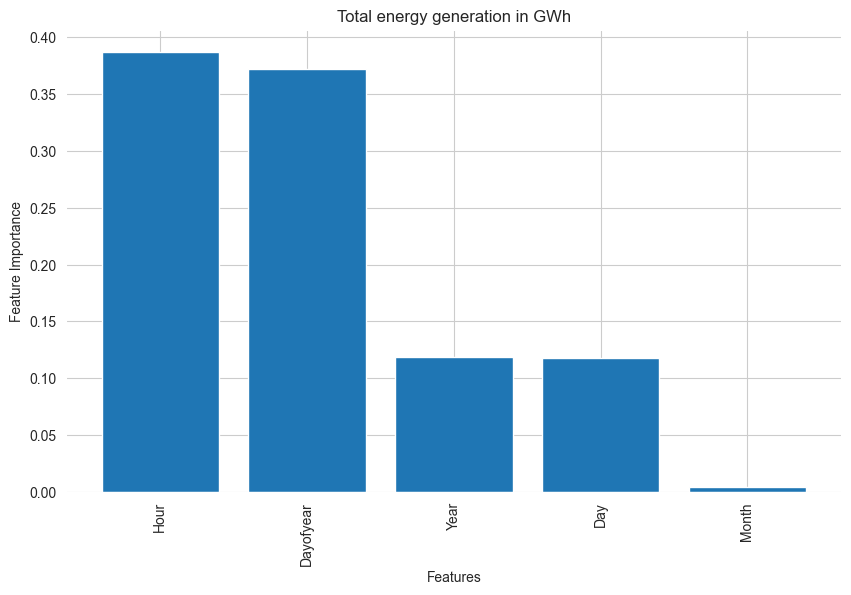

In [636]:

# Get the feature importances
importances = rf_reg.feature_importances_
# Create a list of feature names
feature_names = X_train.columns
# Sort feature importances in descending order
indices = importances.argsort()[::-1]
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature Importance')
plt.title(title_main)
plt.show()

In [637]:
#test_rf['prediction'].loc[(test_rf['prediction'].index > '2023-01-01') & (test_rf['prediction'].index < '2023-12-01') ].plot(figsize=(15,5), ylabel=ylable_target)
#ax.legend(['2023 data'])
#plt.show()

#### RandomForestRegressor with  StandardScaler() 

Mean Squared Error (MSE): 94.61518559374085
Mean Absolute Error (MAE): 7.588313804445884
Root Mean Squared Error (RMSE): 9.727033751033295
R-squared (R2): 0.2765945957260838


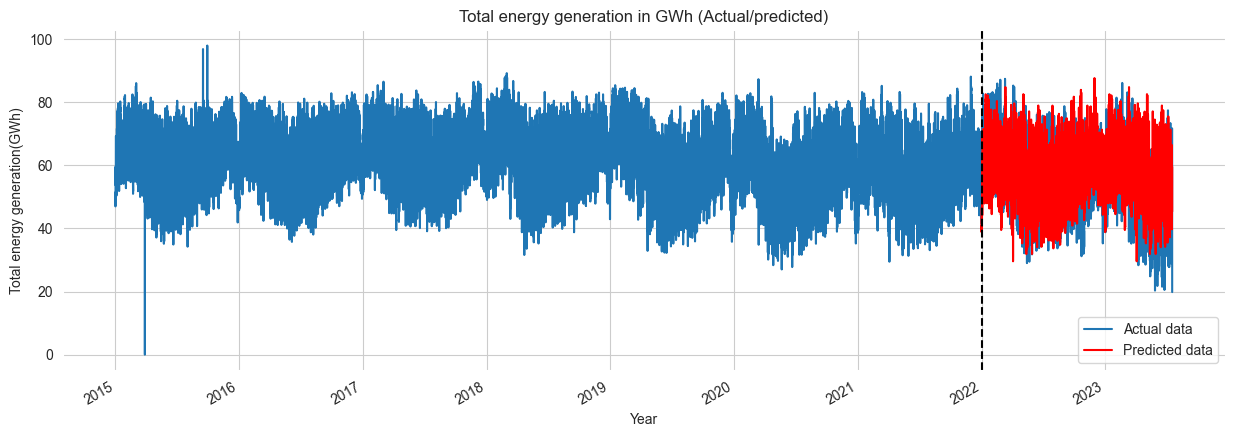

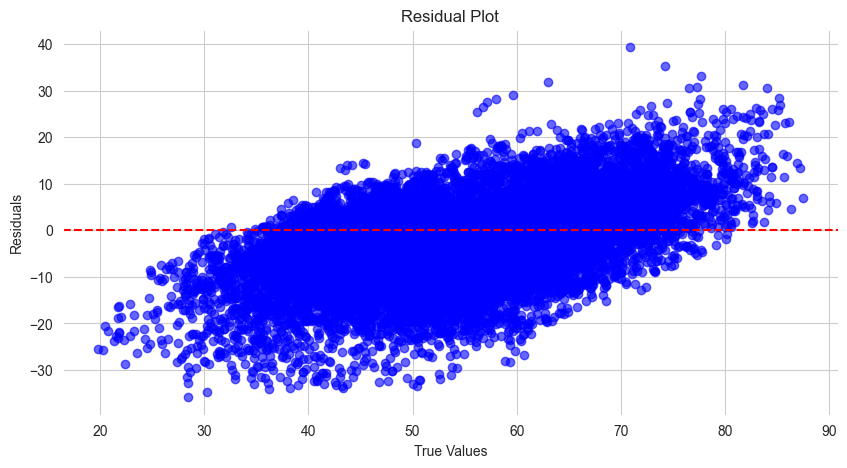

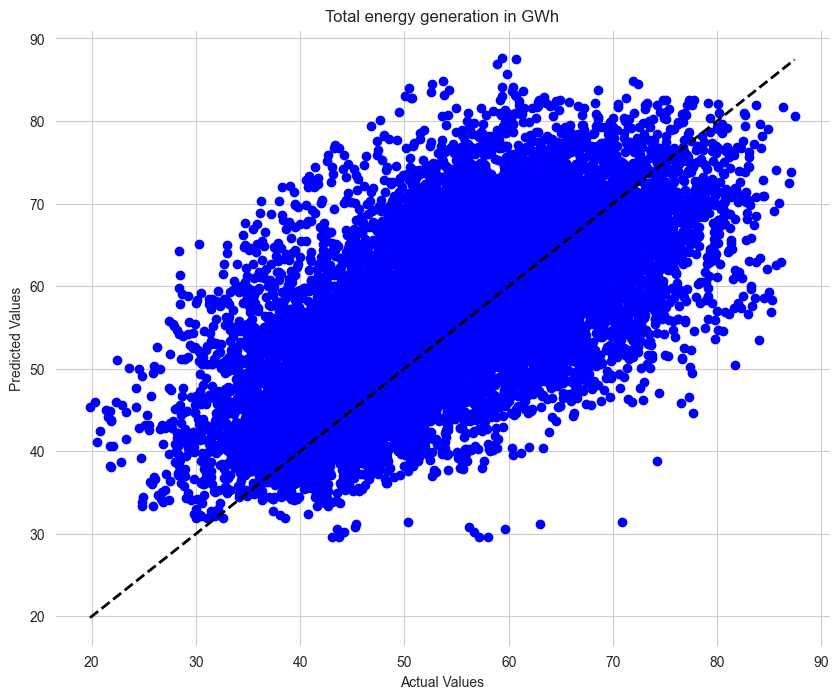

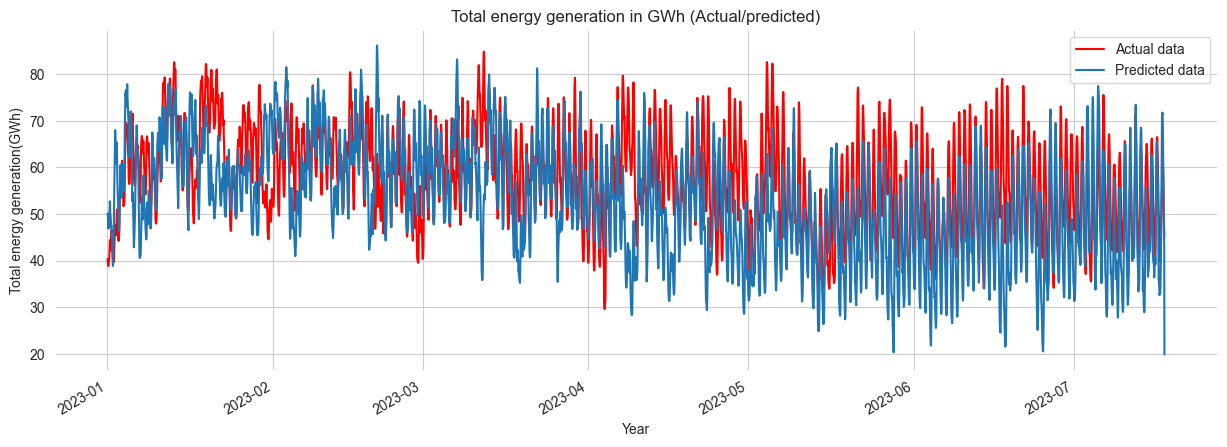

In [638]:
# Extract features and target variables
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=1000, random_state=42)

# Fit the model on the scaled training data
rf_reg.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
test['prediction'] = rf_reg.predict(X_test_scaled)

# Calculate evaluation metrics on the unscaled predictions
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15, 5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

# Plotting predicted vs actual values for the year 2023 only
fig, ax = plt.subplots(figsize=(15, 5))
test['prediction'].loc[(test.index > '2023-01-01') & (test.index < '2023-12-01')].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01')].plot(ax=ax, color='#1f76b4', label='Actual Data')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()


#### RandomForestRegressor with  MinMaxScaler()

Mean Squared Error (MSE): 94.63041368899445
Mean Absolute Error (MAE): 7.587760513206987
Root Mean Squared Error (RMSE): 9.727816491330131
R-squared (R2): 0.27647816529967684


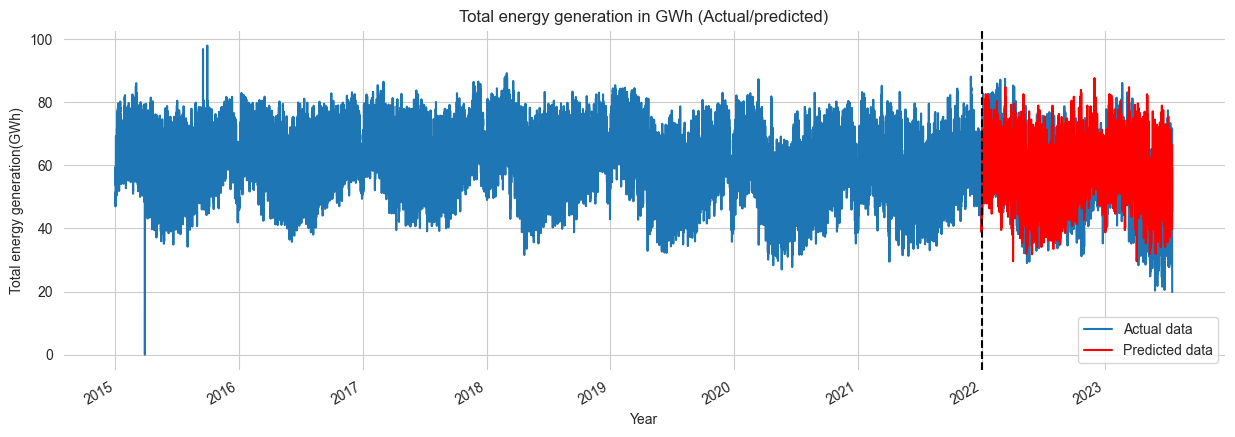

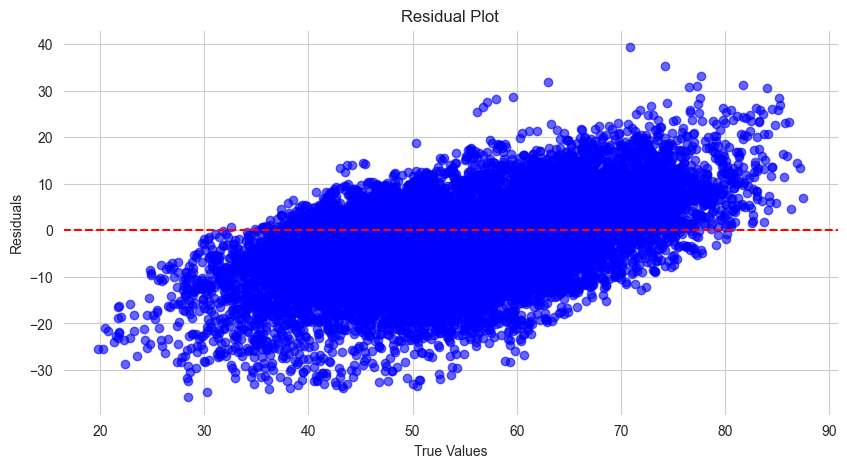

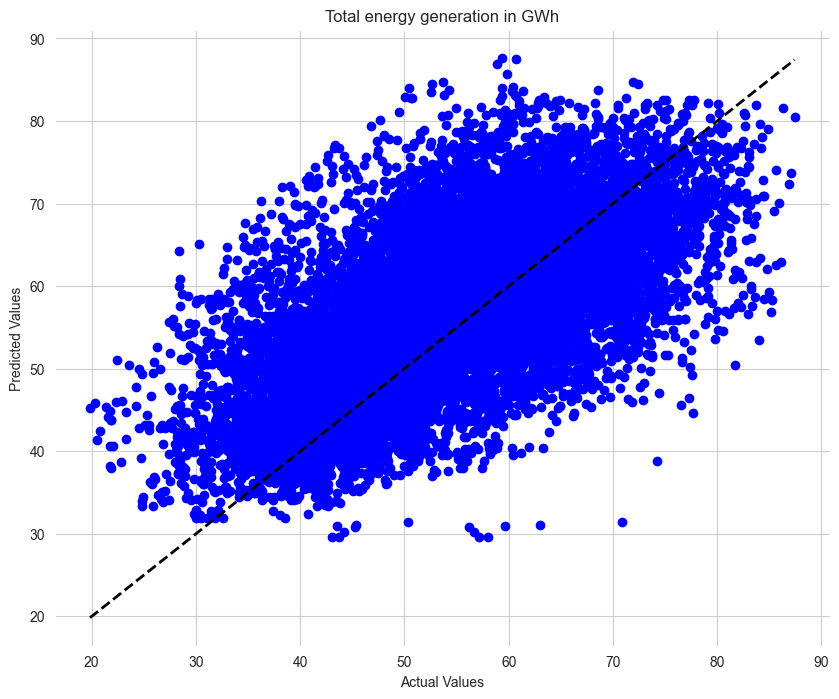

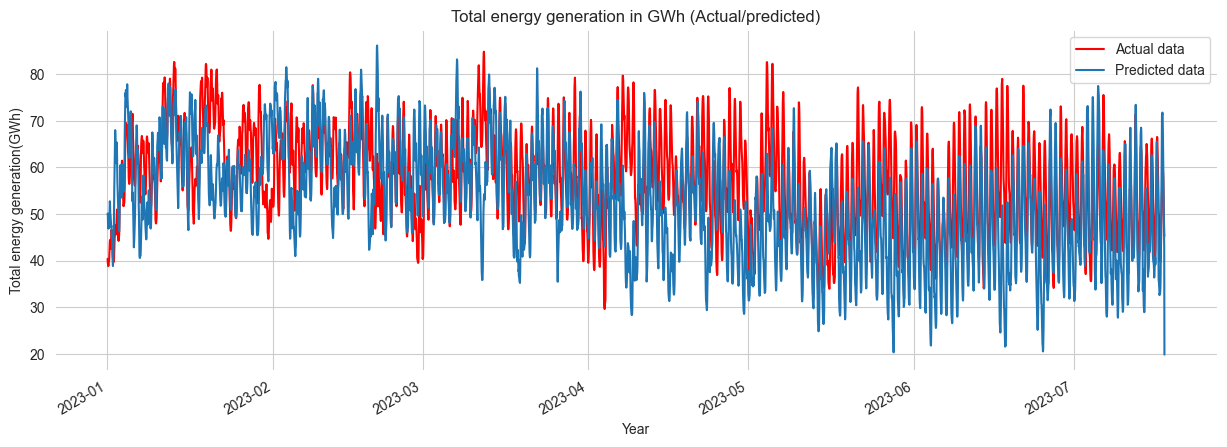

In [639]:
# Extract features and target variables
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=1000, random_state=42)

# Fit the model on the scaled training data
rf_reg.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
test['prediction'] = rf_reg.predict(X_test_scaled)

# Calculate evaluation metrics on the unscaled predictions
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15, 5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)##
#plt.legend()
plt.show()

# Plotting predicted vs actual values for the year 2023 only
fig, ax = plt.subplots(figsize=(15, 5))
test['prediction'].loc[(test.index > '2023-01-01') & (test.index < '2023-12-01')].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01')].plot(ax=ax, color='#1f76b4', label='Actual Data')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()


#### Grid search for Random Forest  

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found during grid search: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 1000}
Mean Squared Error (MSE): 67.35794315303824
Mean Absolute Error (MAE): 6.470768022076075
Root Mean Squared Error (RMSE): 8.207188504782758
R-squared (R2): 0.484997045750058


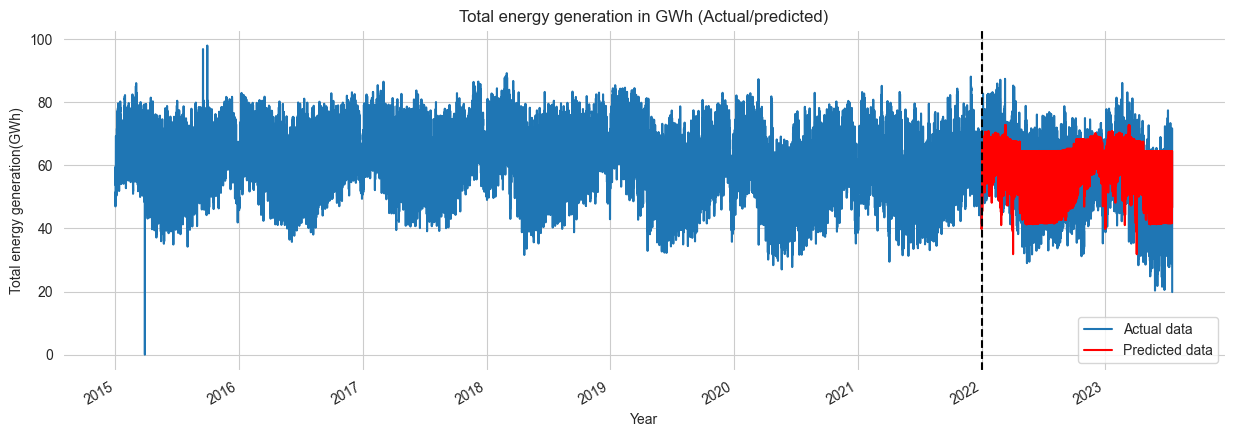

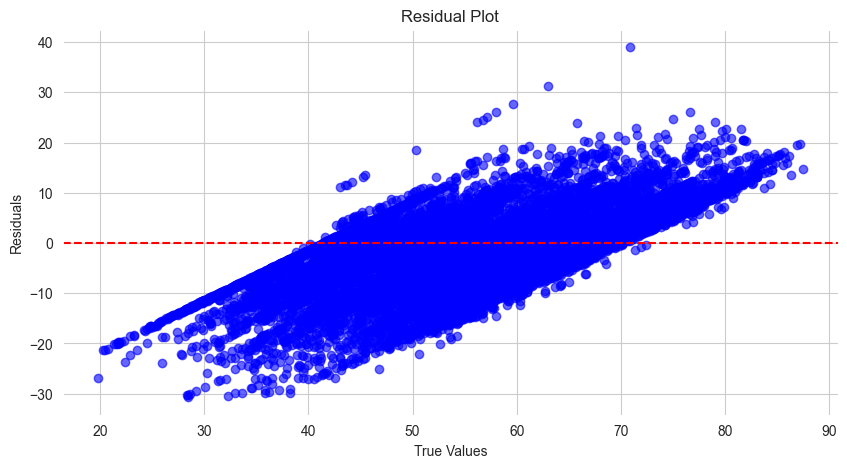

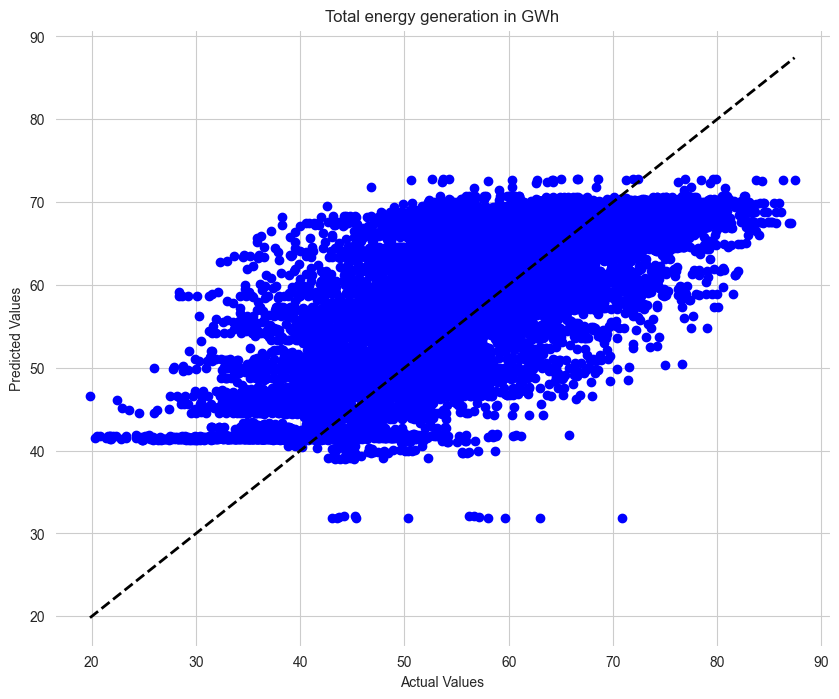

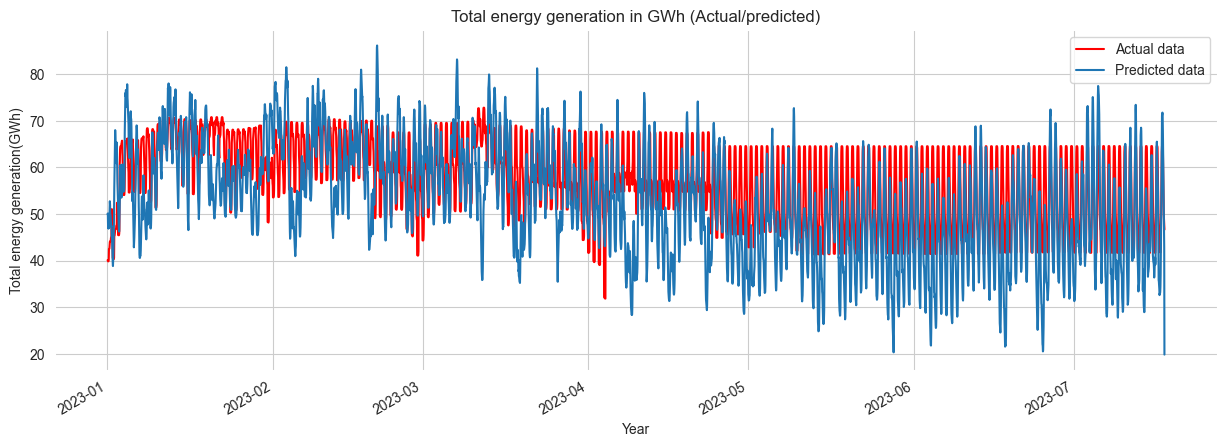

In [640]:
from sklearn.model_selection import GridSearchCV
# Extract features and target variables
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)

# Define hyperparameters for the grid search
param_grid = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=rf_reg, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit the grid search on the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Get the best model from the grid search
best_rf_reg = grid_search.best_estimator_

# Make predictions on the scaled test set
test['prediction'] = best_rf_reg.predict(X_test_scaled)

# Calculate evaluation metrics on the unscaled predictions
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Best parameters found during grid search:", grid_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15, 5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

# Plotting predicted vs actual values for the year 2023 only
fig, ax = plt.subplots(figsize=(15, 5))
test['prediction'].loc[(test.index > '2023-01-01') & (test.index < '2023-12-01')].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01')].plot(ax=ax, color='#1f76b4', label='Actual Data')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()


#### Random search for Random Forest

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found during random search: {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
Mean Squared Error (MSE): 67.38553976796774
Mean Absolute Error (MAE): 6.472114693376574
Root Mean Squared Error (RMSE): 8.208869579178838
R-squared (R2): 0.484786048537989


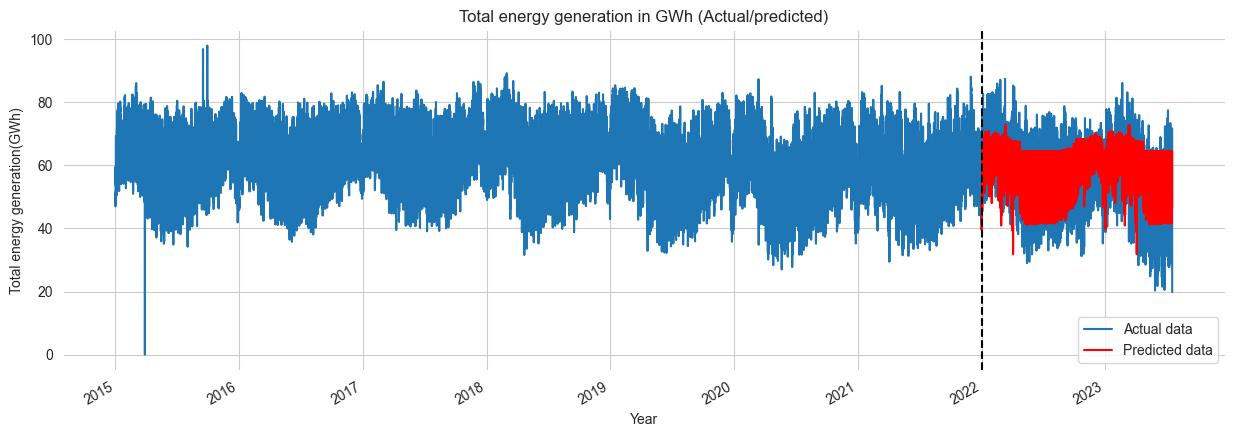

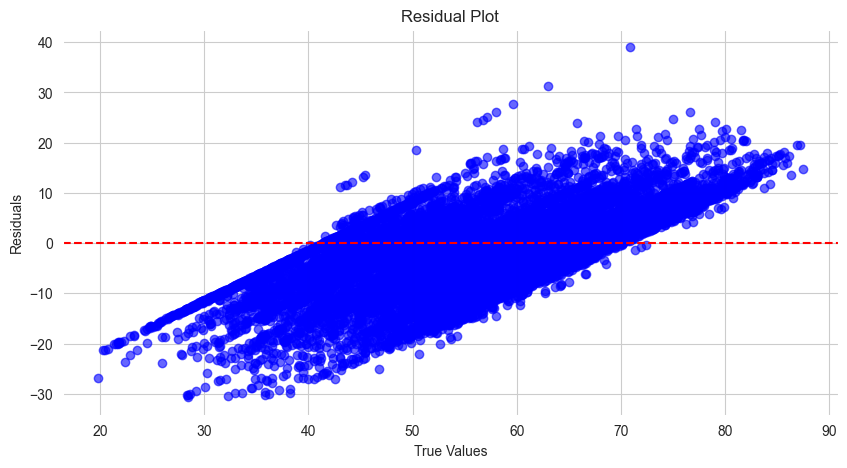

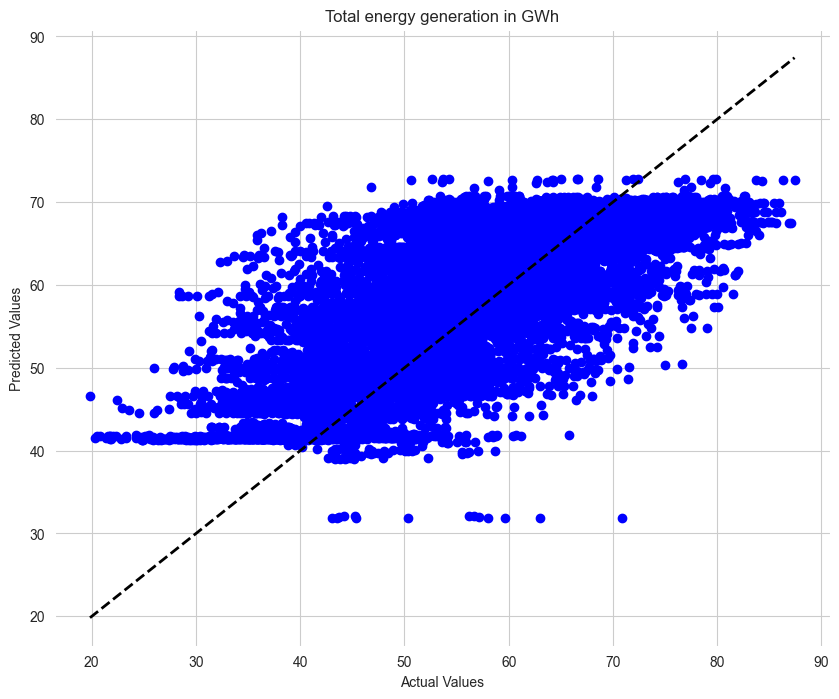

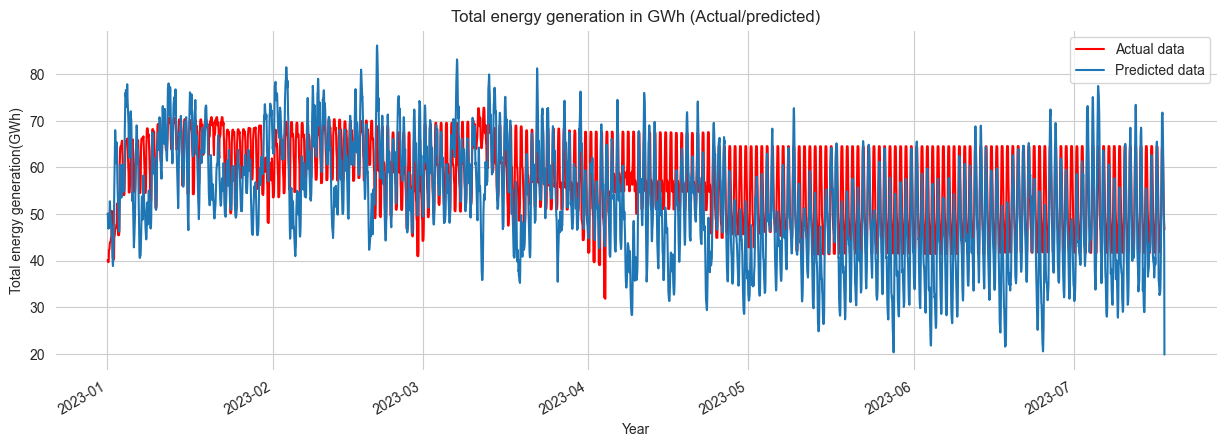

In [641]:
from sklearn.model_selection import RandomizedSearchCV

# Extract features and target variables
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)

# Define hyperparameters for the random search
param_dist = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a RandomizedSearchCV object
random_search = RandomizedSearchCV(estimator=rf_reg, param_distributions=param_dist, n_iter=10, cv=5, n_jobs=-1, random_state=42, verbose=1)

# Fit the random search on the scaled training data
random_search.fit(X_train_scaled, y_train)

# Get the best model from the random search
best_rf_reg = random_search.best_estimator_

# Make predictions on the scaled test set
test['prediction'] = best_rf_reg.predict(X_test_scaled)

# Calculate evaluation metrics on the unscaled predictions
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Best parameters found during random search:", random_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15, 5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label='', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
#plt.legend()
plt.show()

# Plotting predicted vs actual values for the year 2023 only
fig, ax = plt.subplots(figsize=(15, 5))
test['prediction'].loc[(test.index > '2023-01-01') & (test.index < '2023-12-01')].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01')].plot(ax=ax, color='#1f76b4', label='Actual Data')
ax.legend(['Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()


##### Monthly sampling

In [128]:

df_dt = create_features(df_dt)
df_dt.head()

#target = 'Total_energy_generation_gwh'
target ='Total_energy_generation_gwh'
print(target)

Total_energy_generation_gwh


[0]	validation_0-rmse:42.53732	validation_1-rmse:37.14824
[1]	validation_0-rmse:30.15682	validation_1-rmse:24.89784
[2]	validation_0-rmse:21.54021	validation_1-rmse:16.51889
[3]	validation_0-rmse:15.48230	validation_1-rmse:11.13026
[4]	validation_0-rmse:11.26259	validation_1-rmse:8.17872
[5]	validation_0-rmse:8.18714	validation_1-rmse:5.80621
[6]	validation_0-rmse:6.04494	validation_1-rmse:4.48268
[7]	validation_0-rmse:4.52419	validation_1-rmse:4.18951
[8]	validation_0-rmse:3.42440	validation_1-rmse:4.03450
[9]	validation_0-rmse:2.62885	validation_1-rmse:3.98462
[10]	validation_0-rmse:2.09865	validation_1-rmse:4.05354
[11]	validation_0-rmse:1.73343	validation_1-rmse:4.09557
[12]	validation_0-rmse:1.44578	validation_1-rmse:4.22114
[13]	validation_0-rmse:1.22590	validation_1-rmse:4.35389
[14]	validation_0-rmse:1.08372	validation_1-rmse:4.47399
[15]	validation_0-rmse:0.93847	validation_1-rmse:4.54519
[16]	validation_0-rmse:0.85575	validation_1-rmse:4.59948
[17]	validation_0-rmse:0.76264	v

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/4048434635.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hour'] = df.index.hour
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/4048434635.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df.index.year
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/4048434635.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

[58]	validation_0-rmse:0.02471	validation_1-rmse:4.92439
[59]	validation_0-rmse:0.02330	validation_1-rmse:4.92412
Mean Squared Error (MSE): 15.877184164346446
Mean Absolute Error (MAE): 3.0640062506348453
Root Mean Squared Error (RMSE): 3.984618446519873
R-squared (R2): 0.5891523629648121


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/4048434635.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = xgb_reg.predict(X_test)


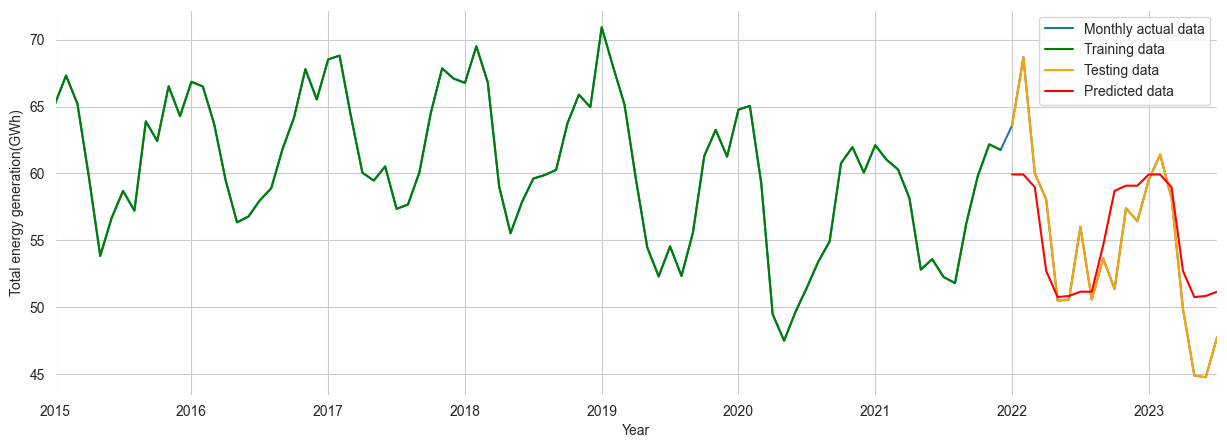

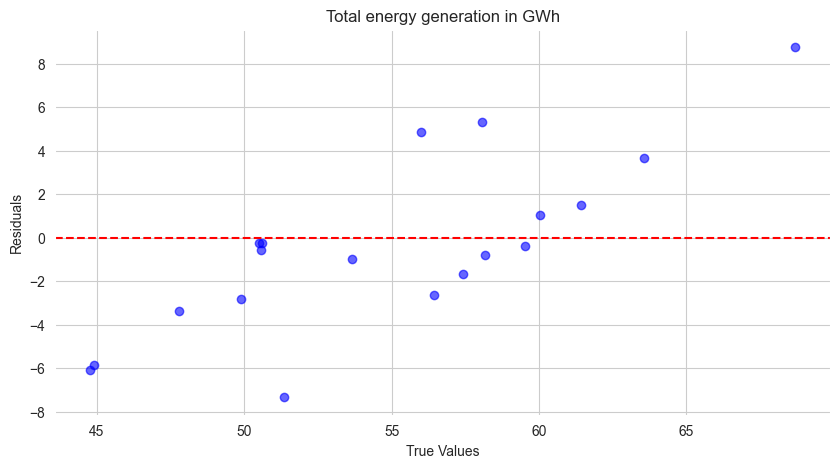

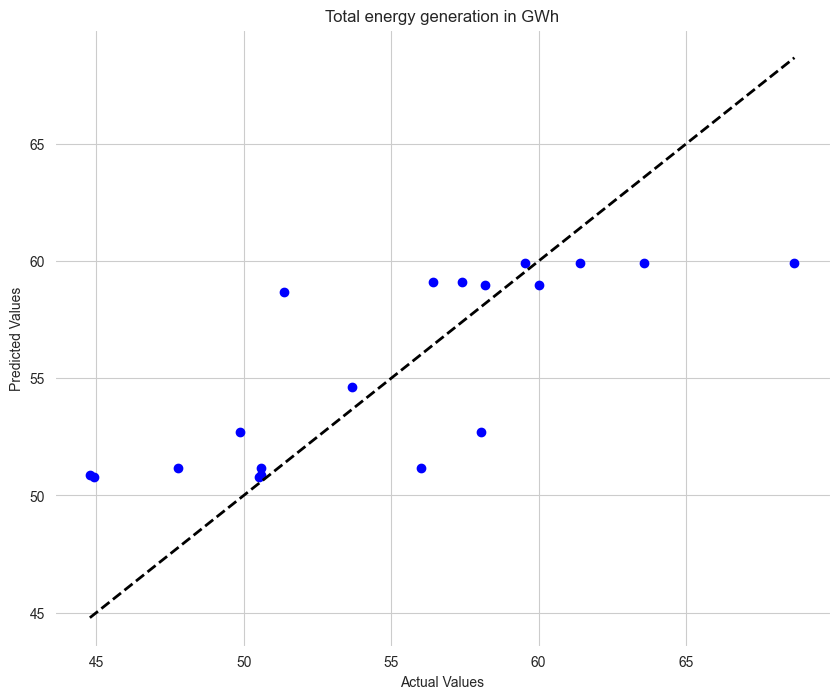

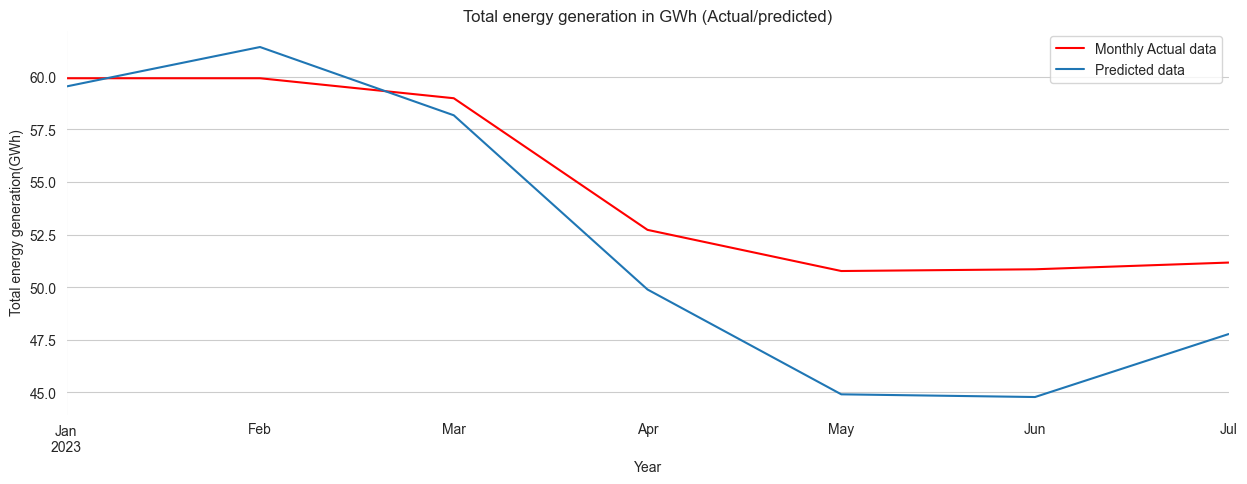

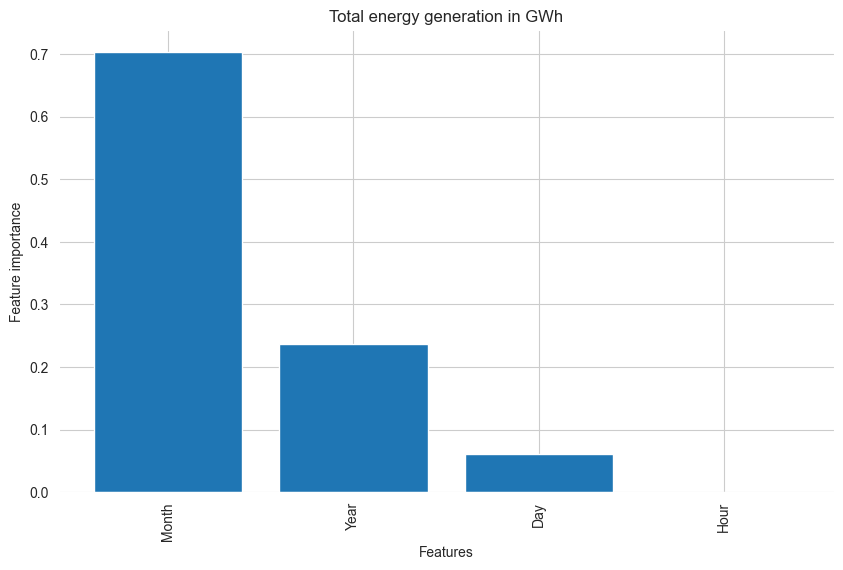

In [130]:

# Resample the data to monthly frequency
df_dt_monthly = df_dt.resample('M').mean()

# Split the resampled data into training and testing sets
train = df_dt_monthly.loc[df_dt_monthly.index < '2022-01-1']
test = df_dt_monthly.loc[df_dt_monthly.index >= '2022-01-1']

# Function to create additional time-based features
def create_features(df):
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
    df['Day'] = df.index.day
    return df

# Create additional time-based features for training and testing sets
train = create_features(train)
test = create_features(test)

# Select features and target
features = ['Hour', 'Year', 'Month', 'Day']
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Train an XGBoost regression model
xgb_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42)
xgb_reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], early_stopping_rounds=50, verbose=True)

# Make predictions on the test set
test['prediction'] = xgb_reg.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot training, testing, and predicted data with respect to df_dt_monthly
fig, ax = plt.subplots(figsize=(15, 5))
df_dt_monthly[target].plot(ax=ax, color='#1f76b4', label='Monthly actual data')
train[target].plot(ax=ax, color='green', label='Training data')
test[target].plot(ax=ax, color='orange', label='Testing data')
test['prediction'].plot(ax=ax, color='red', label='Predicted data')
ax.legend(['Monthly actual data', 'Training data', 'Testing data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
plt.show()

fig, ax = plt.subplots(figsize=(15, 5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-31')].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt_monthly[target].loc[(df_dt_monthly[target].index > '2023-01-01') & (df_dt_monthly[target].index < '2023-12-31')].plot(ax=ax, color='#1f76b4', label='Monthly Actual Data')
ax.legend(['Monthly Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Get the feature importances
importances = xgb_reg.feature_importances_
feature_names = X_train.columns
indices = importances.argsort()[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title(title_main)
plt.show()


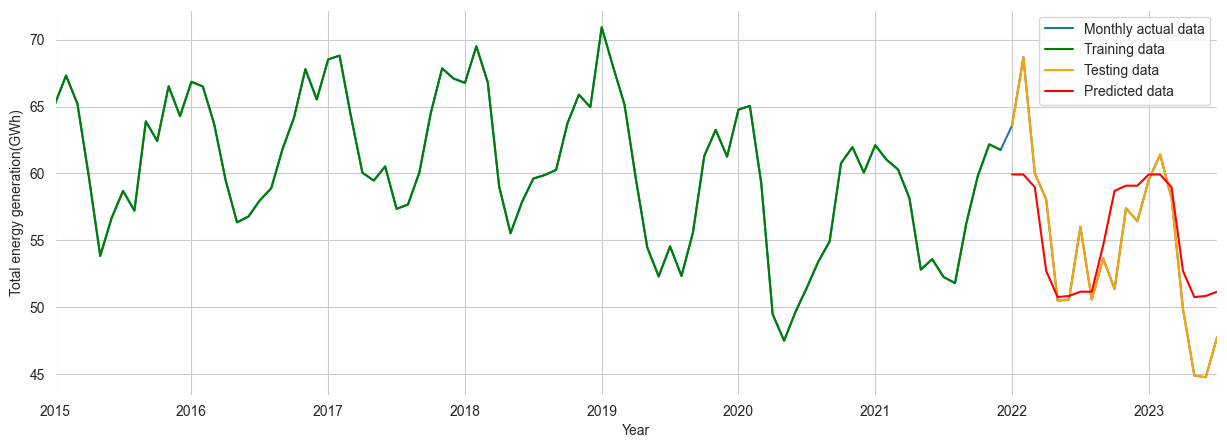

In [135]:
# Plot training, testing, and predicted data with respect to df_dt_monthly
fig, ax = plt.subplots(figsize=(15, 5))
df_dt_monthly[target].plot(ax=ax, color='#1f76b4', label='Monthly actual data')
train[target].plot(ax=ax, color='green', label='Training data')
test[target].plot(ax=ax, color='orange', label='Testing data')
test['prediction'].plot(ax=ax, color='red', label='Predicted data')
ax.legend(['Monthly actual data', 'Training data', 'Testing data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

#### Daily Sampling

[0]	validation_0-rmse:42.57660	validation_1-rmse:37.76155
[1]	validation_0-rmse:30.13515	validation_1-rmse:26.36900
[2]	validation_0-rmse:21.53103	validation_1-rmse:18.29311
[3]	validation_0-rmse:15.60859	validation_1-rmse:13.12076
[4]	validation_0-rmse:11.63871	validation_1-rmse:9.86654
[5]	validation_0-rmse:8.99323	validation_1-rmse:8.06522
[6]	validation_0-rmse:7.32630	validation_1-rmse:7.23748
[7]	validation_0-rmse:6.29224	validation_1-rmse:6.91907
[8]	validation_0-rmse:5.70064	validation_1-rmse:6.89222
[9]	validation_0-rmse:5.34532	validation_1-rmse:7.01431
[10]	validation_0-rmse:5.14194	validation_1-rmse:7.11493
[11]	validation_0-rmse:5.01084	validation_1-rmse:7.18482
[12]	validation_0-rmse:4.94613	validation_1-rmse:7.21447
[13]	validation_0-rmse:4.90293	validation_1-rmse:7.25552
[14]	validation_0-rmse:4.85035	validation_1-rmse:7.32020
[15]	validation_0-rmse:4.79099	validation_1-rmse:7.37509
[16]	validation_0-rmse:4.77178	validation_1-rmse:7.41691
[17]	validation_0-rmse:4.72663	v

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/2363395958.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hour'] = df.index.hour
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/2363395958.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df.index.year
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/2363395958.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

[50]	validation_0-rmse:3.89332	validation_1-rmse:8.10293
[51]	validation_0-rmse:3.86990	validation_1-rmse:8.11750
[52]	validation_0-rmse:3.85574	validation_1-rmse:8.11715
[53]	validation_0-rmse:3.84257	validation_1-rmse:8.10628
[54]	validation_0-rmse:3.83334	validation_1-rmse:8.10740
[55]	validation_0-rmse:3.81419	validation_1-rmse:8.11003
[56]	validation_0-rmse:3.79981	validation_1-rmse:8.10752
[57]	validation_0-rmse:3.78324	validation_1-rmse:8.11488
Mean Squared Error (MSE): 47.50271021147391
Mean Absolute Error (MAE): 5.335444142072642
Root Mean Squared Error (RMSE): 6.892220992646268
R-squared (R2): 0.3061468047765712


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/2363395958.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = xgb_reg.predict(X_test)


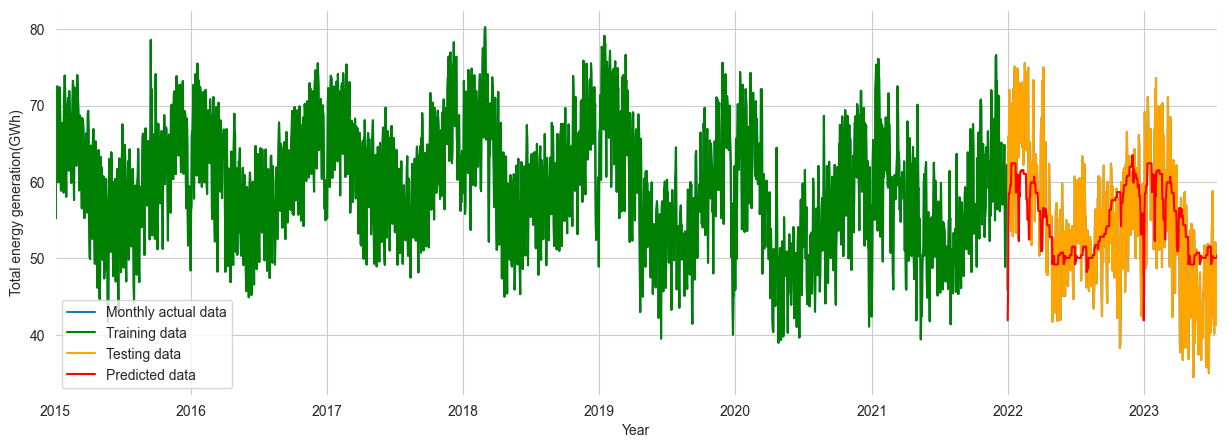

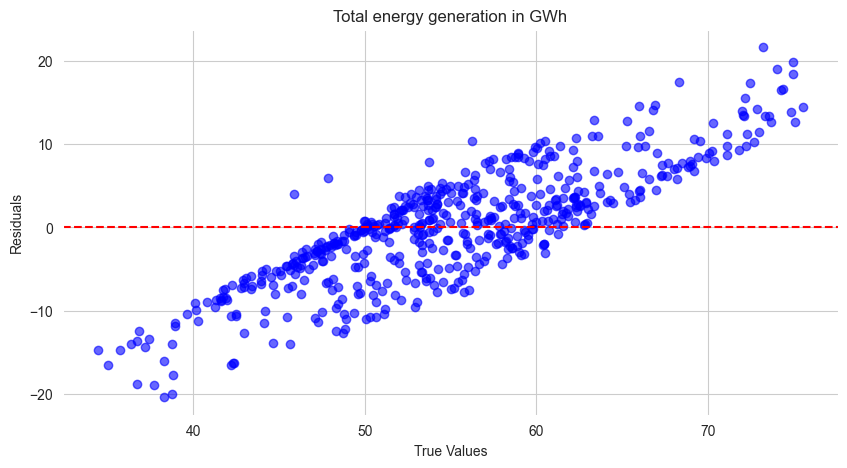

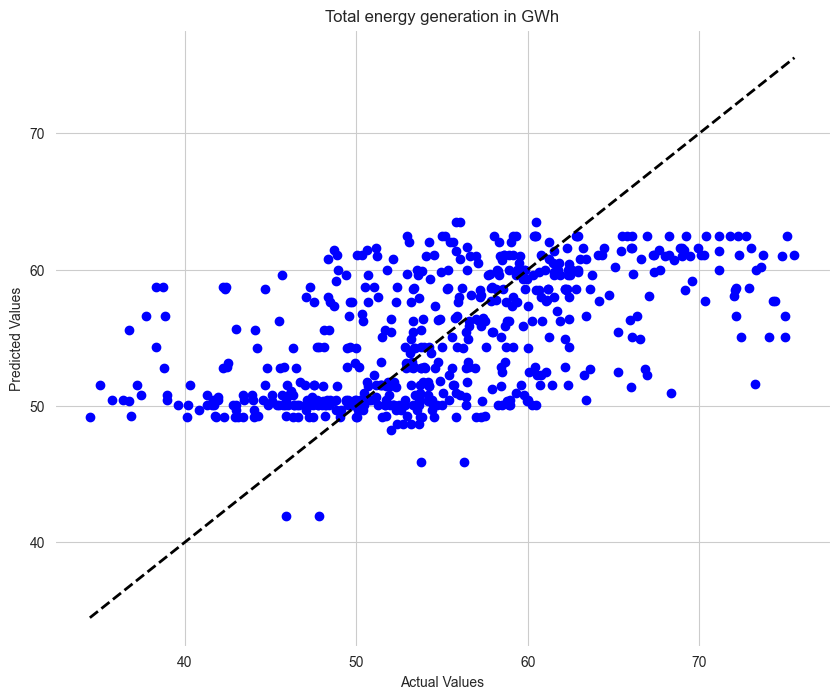

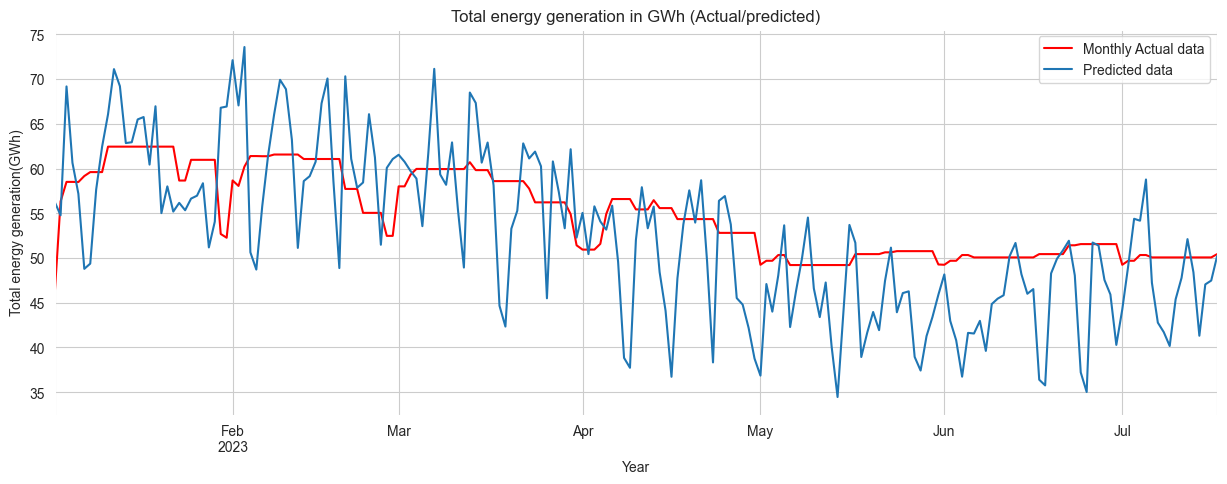

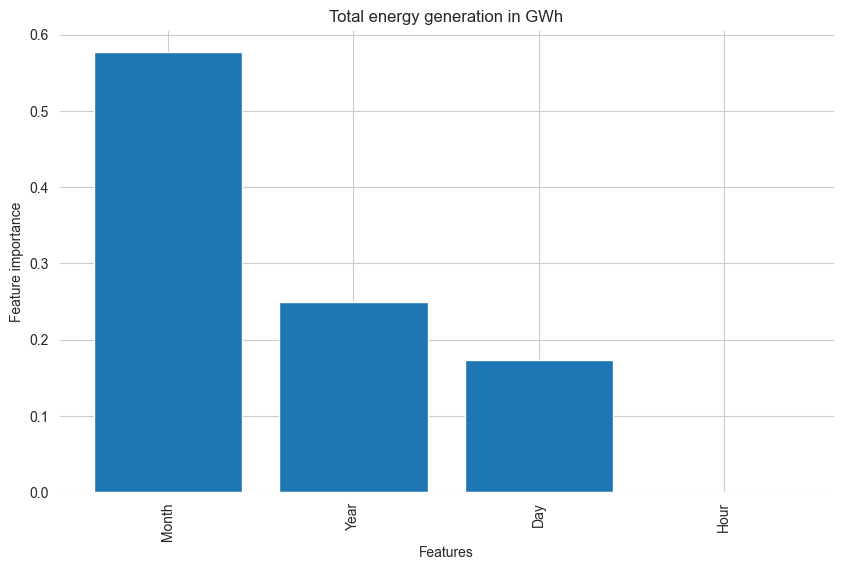

In [136]:

# Resample the data to monthly frequency
df_dt_monthly = df_dt.resample('D').mean()

# Split the resampled data into training and testing sets
train = df_dt_monthly.loc[df_dt_monthly.index < '2022-01-1']
test = df_dt_monthly.loc[df_dt_monthly.index >= '2022-01-1']

# Function to create additional time-based features
def create_features(df):
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
    df['Day'] = df.index.day
    return df

# Create additional time-based features for training and testing sets
train = create_features(train)
test = create_features(test)

# Select features and target
features = ['Hour', 'Year', 'Month', 'Day']
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Train an XGBoost regression model
xgb_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42)
xgb_reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], early_stopping_rounds=50, verbose=True)

# Make predictions on the test set
test['prediction'] = xgb_reg.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot training, testing, and predicted data with respect to df_dt_monthly
fig, ax = plt.subplots(figsize=(15, 5))
df_dt_monthly[target].plot(ax=ax, color='#1f76b4', label='Monthly actual data')
train[target].plot(ax=ax, color='green', label='Training data')
test[target].plot(ax=ax, color='orange', label='Testing data')
test['prediction'].plot(ax=ax, color='red', label='Predicted data')
ax.legend(['Monthly actual data', 'Training data', 'Testing data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
plt.show()

fig, ax = plt.subplots(figsize=(15, 5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-31')].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt_monthly[target].loc[(df_dt_monthly[target].index > '2023-01-01') & (df_dt_monthly[target].index < '2023-12-31')].plot(ax=ax, color='#1f76b4', label='Monthly Actual Data')
ax.legend(['Monthly Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Year')
plt.show()

# Get the feature importances
importances = xgb_reg.feature_importances_
feature_names = X_train.columns
indices = importances.argsort()[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title(title_main)
plt.show()


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/1463267895.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hour'] = df.index.hour
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/1463267895.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df.index.year
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/1463267895.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

[0]	validation_0-rmse:59.85978	validation_1-rmse:54.55242
[1]	validation_0-rmse:59.26850	validation_1-rmse:53.97713
[2]	validation_0-rmse:58.68318	validation_1-rmse:53.40768
[3]	validation_0-rmse:58.10378	validation_1-rmse:52.84402
[4]	validation_0-rmse:57.53022	validation_1-rmse:52.28610
[5]	validation_0-rmse:56.96245	validation_1-rmse:51.73385
[6]	validation_0-rmse:56.40043	validation_1-rmse:51.18722
[7]	validation_0-rmse:55.84407	validation_1-rmse:50.64616
[8]	validation_0-rmse:55.29335	validation_1-rmse:50.11060
[9]	validation_0-rmse:54.74818	validation_1-rmse:49.58051
[10]	validation_0-rmse:54.20853	validation_1-rmse:49.05582
[11]	validation_0-rmse:53.67434	validation_1-rmse:48.53648
[12]	validation_0-rmse:53.14555	validation_1-rmse:48.02244
[13]	validation_0-rmse:52.62212	validation_1-rmse:47.51364
[14]	validation_0-rmse:52.10397	validation_1-rmse:47.02289
[15]	validation_0-rmse:51.59107	validation_1-rmse:46.53715
[16]	validation_0-rmse:51.08336	validation_1-rmse:46.04379
[17]	va

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[119]	validation_0-rmse:19.00526	validation_1-rmse:16.33847
[120]	validation_0-rmse:18.83352	validation_1-rmse:16.18612
[121]	validation_0-rmse:18.66370	validation_1-rmse:16.03734
[122]	validation_0-rmse:18.49577	validation_1-rmse:15.88429
[123]	validation_0-rmse:18.32967	validation_1-rmse:15.73631
[124]	validation_0-rmse:18.16527	validation_1-rmse:15.59326
[125]	validation_0-rmse:18.00275	validation_1-rmse:15.44842
[126]	validation_0-rmse:17.84203	validation_1-rmse:15.30269
[127]	validation_0-rmse:17.68297	validation_1-rmse:15.16493
[128]	validation_0-rmse:17.52576	validation_1-rmse:15.02276
[129]	validation_0-rmse:17.37025	validation_1-rmse:14.88824
[130]	validation_0-rmse:17.21649	validation_1-rmse:14.75283
[131]	validation_0-rmse:17.06430	validation_1-rmse:14.62188
[132]	validation_0-rmse:16.91391	validation_1-rmse:14.48656
[133]	validation_0-rmse:16.76504	validation_1-rmse:14.35906
[134]	validation_0-rmse:16.61794	validation_1-rmse:14.22971
[135]	validation_0-rmse:16.47251	validat

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/1463267895.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = xgb_reg.predict(X_test)


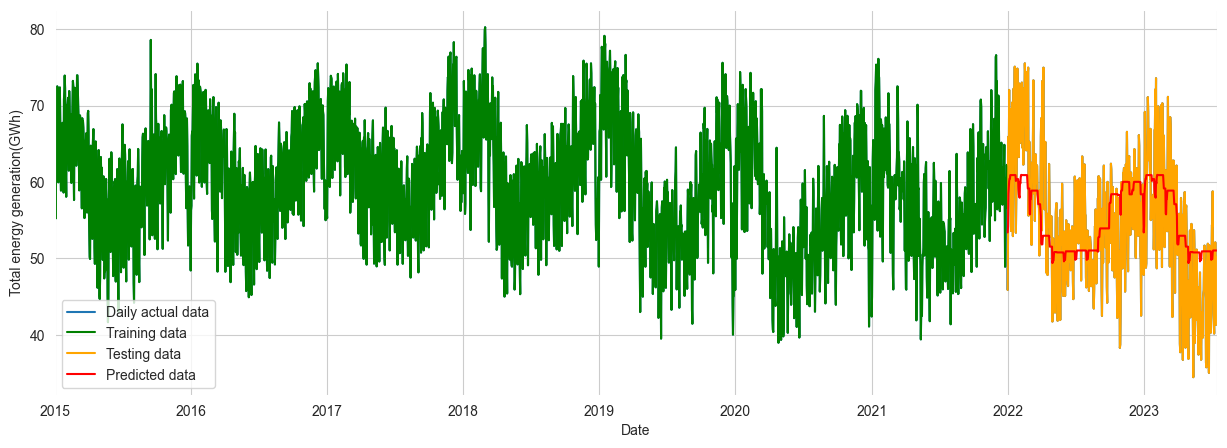

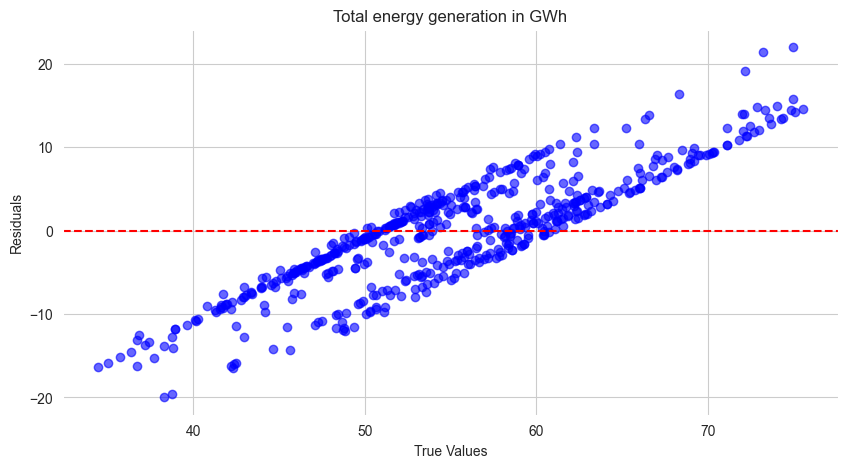

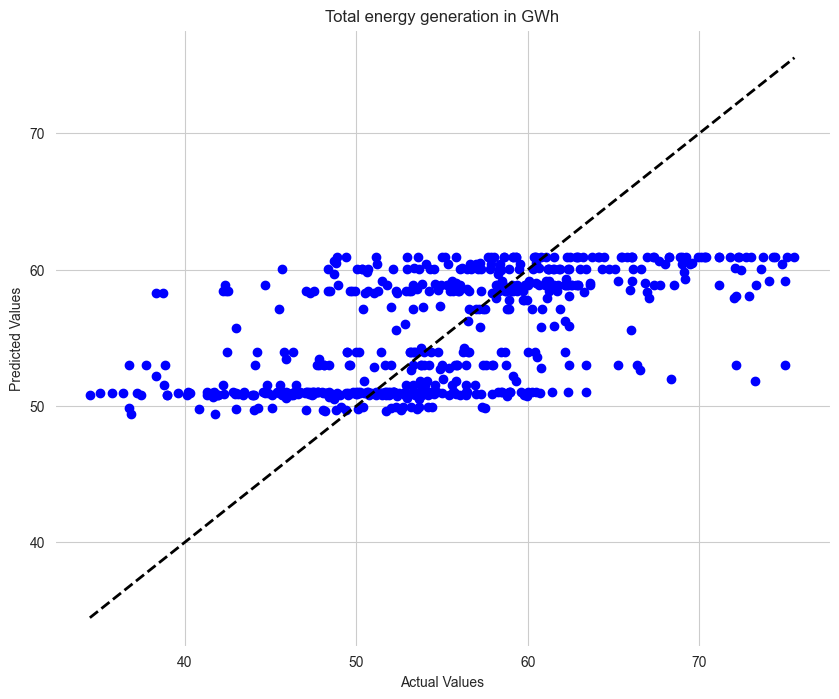

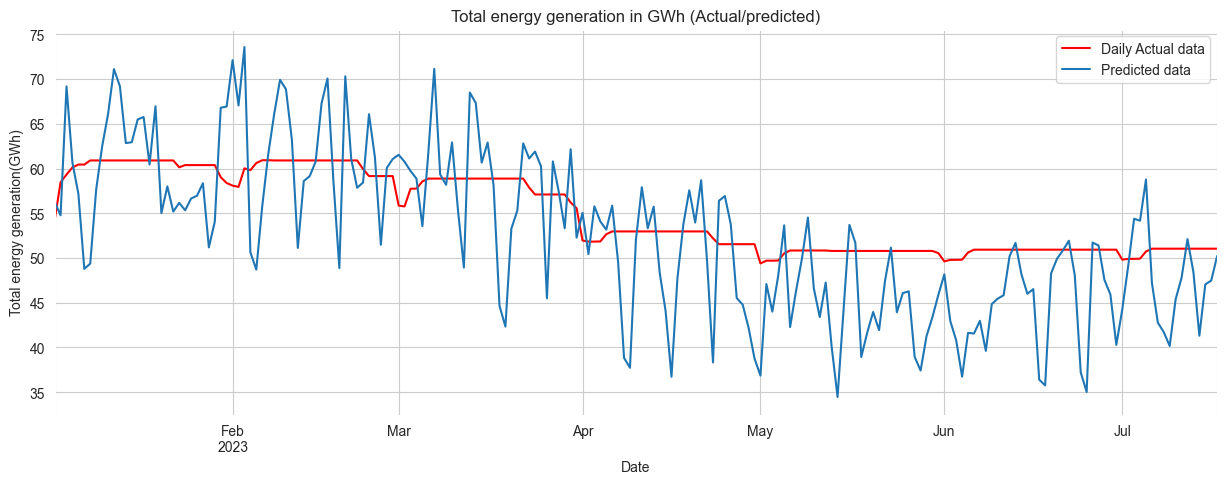

In [141]:
from sklearn.model_selection import GridSearchCV
# Resample the data to daily frequency
df_dt_daily = df_dt.resample('D').mean()

# Split the resampled data into training and testing sets
train = df_dt_daily.loc[df_dt_daily.index < '2022-01-01']
test = df_dt_daily.loc[df_dt_daily.index >= '2022-01-01']

# Function to create additional time-based features
def create_features(df):
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
    df['Day'] = df.index.day
    return df

# Create additional time-based features for training and testing sets
train = create_features(train)
test = create_features(test)

# Select features and target
features = ['Hour', 'Year', 'Month', 'Day']
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Hyperparameter Grid for Grid Search
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.001, 0.01, 0.1],
    'max_depth': [3, 5, 7],
}

# Create an XGBoost regression model
xgb_reg = xgb.XGBRegressor(random_state=42)

# Grid Search for hyperparameter tuning
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters from Grid Search
best_params = grid_search.best_params_

# Train the XGBoost regression model with the best hyperparameters
xgb_reg = xgb.XGBRegressor(n_estimators=best_params['n_estimators'], 
                           learning_rate=best_params['learning_rate'],
                           max_depth=best_params['max_depth'],
                           random_state=42)
xgb_reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], early_stopping_rounds=50, verbose=True)

# Make predictions on the test set
test['prediction'] = xgb_reg.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot training, testing, and predicted data with respect to df_dt_daily
fig, ax = plt.subplots(figsize=(15, 5))
df_dt_daily[target].plot(ax=ax, color='#1f76b4', label='Daily actual data')
train[target].plot(ax=ax, color='green', label='Training data')
test[target].plot(ax=ax, color='orange', label='Testing data')
test['prediction'].plot(ax=ax, color='red', label='Predicted data')
ax.legend(['Daily actual data', 'Training data', 'Testing data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
plt.show()

fig, ax = plt.subplots(figsize=(15, 5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-31')].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt_daily[target].loc[(df_dt_daily[target].index > '2023-01-01') & (df_dt_daily[target].index < '2023-12-31')].plot(ax=ax, color='#1f76b4', label='Daily Actual Data')
ax.legend(['Daily Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.show()

# Get the feature importances



#### Hourly Sampling

In [138]:

# Resample the data to hourly frequency
df_dt_hourly = df_dt.resample('H').mean()

# Split the resampled data into training and testing sets
train = df_dt_hourly.loc[df_dt_hourly.index < '2022-01-01']
test = df_dt_hourly.loc[df_dt_hourly.index >= '2022-01-01']

# Function to create additional time-based features
def create_features(df):
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
    df['Day'] = df.index.day
    return df

# Create additional time-based features for training and testing sets
train = create_features(train)
test = create_features(test)

# Select features and target
features = ['Hour', 'Year', 'Month', 'Day']
X_train = train[features]
X_test = test[features]
y_train = train[target]
y_test = test[target]

# Train an XGBoost regression model
xgb_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42)
xgb_reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], early_stopping_rounds=50, verbose=True)

# Make predictions on the test set
test['prediction'] = xgb_reg.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot training, testing, and predicted data with respect to df_dt_hourly
fig, ax = plt.subplots(figsize=(15, 5))
df_dt_hourly[target].plot(ax=ax, color='#1f76b4', label='Hourly actual data')
train[target].plot(ax=ax, color='green', label='Training data')
test[target].plot(ax=ax, color='orange', label='Testing data')
test['prediction'].plot(ax=ax, color='red', label='Predicted data')
ax.legend(['Hourly actual data', 'Training data', 'Testing data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.show()

# Calculate residuals
residuals = y_test - test['prediction']

# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main)
plt.show()

fig, ax = plt.subplots(figsize=(15, 5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-31')].plot(ax=ax, color='red', label='Predicted Data', title=title_main + ' ' + '(Actual/predicted)')
df_dt_hourly[target].loc[(df_dt_hourly[target].index > '2023-01-01') & (df_dt_hourly[target].index < '2023-12-31')].plot(ax=ax, color='#1f76b4', label='Hourly Actual Data')
ax.legend(['Hourly Actual data', 'Predicted data'])
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.show()

# Get the feature importances
importances = xgb_reg.feature_importances_
feature_names = X_train.columns
indices = importances.argsort()[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title(title_main)
plt.show()


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/581837034.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hour'] = df.index.hour
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/581837034.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df.index.year
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_69368/581837034.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

XGBoostError: [23:04:23] /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/data/data.cc:461: Check failed: valid: Label contains NaN, infinity or a value too large.
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x000000017f5a99f8 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x000000017f62e064 xgboost::MetaInfo::SetInfoFromHost(xgboost::GenericParameter const&, xgboost::StringView, xgboost::Json) + 3948
  [bt] (2) 3   libxgboost.dylib                    0x000000017f62cf9c xgboost::MetaInfo::SetInfo(xgboost::GenericParameter const&, xgboost::StringView, xgboost::StringView) + 164
  [bt] (3) 4   libxgboost.dylib                    0x000000017f5be630 XGDMatrixSetInfoFromInterface + 224
  [bt] (4) 5   libffi.dylib                        0x00000001ad9e0050 ffi_call_SYSV + 80
  [bt] (5) 6   libffi.dylib                        0x00000001ad9e8ae8 ffi_call_int + 1208
  [bt]